In [1]:
import pandas as pd
import os
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:

def beautify_chart(ax=None, grid='y', offset=10):

    if ax is None:
        ax = plt.gca()
        

    ax.spines[['right', 'top']].set_visible(False)
    
    ax.spines[['left', 'bottom']].set_color('#CCCCCC')
    ax.spines[['left', 'bottom']].set_linewidth(1.2)
    
    if offset > 0:
        ax.spines['left'].set_position(('outward', offset))
        ax.spines['bottom'].set_position(('outward', offset))
        
    if grid:
        ax.grid(axis=grid, linestyle='--', linewidth=0.8, color='#E5E5E5', zorder=0)
        ax.set_axisbelow(True) 
        
    ax.tick_params(axis='both', colors='#555555', labelsize=10, width=1.2, length=4)
    
    for label in ax.get_xticklabels():
        label.set_weight('bold')
        label.set_color('#444444')
    for label in ax.get_yticklabels():
        label.set_weight('bold')
        label.set_color('#444444')
        
    if ax.get_title():
        ax.set_title(
            ax.get_title(), 
            loc='left',          
            fontsize=13, 
            pad=15,              
            weight='bold', 
            color='#222222'      
        )


# Introduction

# NYC Taxi Data

Project Description :

    I gathered whole green taxi data for NYC in 2025 to uncover patterns, insights, and key questions.
    in this project I use data cleaning , data processing , feature engineering , EDA , data visulation for
    achieving best result in finding insights to improve the bussines target.
    

# Data Reading & Understanding

In [3]:
CurDir = os.getcwd()
path = CurDir+'/green_taxi_data/'
text_files = os.listdir(path)
file_list = []
print('Reading data ...')
for text_file in text_files :
    file_name = path+text_file
    df = pd.read_parquet(file_name)
    file_list.append(df)
green_taxi_df = pd.concat(file_list)

green_taxi_df_copy = green_taxi_df.copy()
green_taxi_df_copy.shape
    

Reading data ...


(591375, 21)

In [4]:
# green_taxi_df_copy.to_csv("../Data/green_taxi_2025.csv")

In [5]:
green_taxi_df_copy.sample(5,random_state=42)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
39147,2,2025-09-27 20:00:35,2025-09-27 20:14:42,N,1.0,74,141,1.0,2.67,15.6,...,0.5,4.17,0.0,NaN,1.0,25.02,1.0,1.0,2.75,0.0
29126,2,2025-09-20 22:06:33,2025-09-20 22:18:28,N,5.0,130,121,1.0,2.18,19.0,...,0.0,3.00,0.0,NaN,1.0,23.00,1.0,2.0,0.00,0.0
10721,2,2025-04-07 13:04:07,2025-04-07 13:06:54,N,1.0,74,41,1.0,0.50,5.1,...,0.5,1.00,0.0,NaN,1.0,7.60,1.0,1.0,0.00,0.0
37518,2,2025-12-27 16:16:38,2025-12-27 16:55:01,N,1.0,82,226,1.0,3.99,34.5,...,0.5,0.00,0.0,NaN,1.0,36.00,2.0,1.0,0.00,0.0
25619,2,2025-07-19 18:27:26,2025-07-19 18:28:02,N,5.0,260,260,1.0,0.15,20.0,...,0.0,3.00,0.0,NaN,1.0,24.00,1.0,2.0,0.00,0.0


In [6]:
green_taxi_df_copy.info()

<class 'pandas.DataFrame'>
Index: 591375 entries, 0 to 48235
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               591375 non-null  int32         
 1   lpep_pickup_datetime   591375 non-null  datetime64[us]
 2   lpep_dropoff_datetime  591375 non-null  datetime64[us]
 3   store_and_fwd_flag     541495 non-null  str           
 4   RatecodeID             541495 non-null  float64       
 5   PULocationID           591375 non-null  int32         
 6   DOLocationID           591375 non-null  int32         
 7   passenger_count        541495 non-null  float64       
 8   trip_distance          591375 non-null  float64       
 9   fare_amount            591375 non-null  float64       
 10  extra                  591375 non-null  float64       
 11  mta_tax                591375 non-null  float64       
 12  tip_amount             591375 non-null  float64       
 13  t

In [7]:
green_taxi_df_copy.isna().sum()

VendorID                      0
lpep_pickup_datetime          0
lpep_dropoff_datetime         0
store_and_fwd_flag        49880
RatecodeID                49880
PULocationID                  0
DOLocationID                  0
passenger_count           49880
trip_distance                 0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
ehail_fee                591375
improvement_surcharge         0
total_amount                  0
payment_type              49880
trip_type                 49927
congestion_surcharge      49880
cbd_congestion_fee         3824
dtype: int64

In [8]:
green_taxi_df_copy.duplicated().sum()

np.int64(0)

data dictionary is available and and be in documention of project :

![alt text](image.png)
![alt text](image-1.png)

# Data Cleaning

check null columns and their percentage

In [9]:
for col in green_taxi_df_copy.columns :
    pct_missing = ((np.mean(green_taxi_df_copy[col].isna()))*100).round(2)
    print('{} - {}%'.format(col,pct_missing))

VendorID - 0.0%
lpep_pickup_datetime - 0.0%
lpep_dropoff_datetime - 0.0%
store_and_fwd_flag - 8.43%
RatecodeID - 8.43%
PULocationID - 0.0%
DOLocationID - 0.0%
passenger_count - 8.43%
trip_distance - 0.0%
fare_amount - 0.0%
extra - 0.0%
mta_tax - 0.0%
tip_amount - 0.0%
tolls_amount - 0.0%
ehail_fee - 100.0%
improvement_surcharge - 0.0%
total_amount - 0.0%
payment_type - 8.43%
trip_type - 8.44%
congestion_surcharge - 8.43%
cbd_congestion_fee - 0.65%


store_and_fwd_flag , RatecodeID , passenger_count , payment_type , trip_type , congestion_surcharge probably nulls values in these columns be the same and have one problem we have to figured out and two columns probably has diffrent algorithm and problem 

In [10]:
green_taxi_df_copy.query("store_and_fwd_flag.isna()")

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
46490,2,2025-01-01 00:56:00,2025-01-01 01:28:00,NaN,NaN,76,188,NaN,2.51,19.26,...,0.5,6.15,0.00,NaN,1.0,26.91,NaN,NaN,NaN,NaN
46491,2,2025-01-01 00:27:00,2025-01-01 00:35:00,NaN,NaN,244,243,NaN,2.69,16.32,...,0.5,2.00,0.00,NaN,1.0,19.82,NaN,NaN,NaN,NaN
46492,2,2025-01-01 00:18:00,2025-01-01 00:32:00,NaN,NaN,129,226,NaN,2.59,21.38,...,0.5,4.58,0.00,NaN,1.0,27.46,NaN,NaN,NaN,NaN
46493,2,2025-01-01 00:59:00,2025-01-01 01:28:00,NaN,NaN,181,112,NaN,8.20,62.18,...,0.5,12.74,0.00,NaN,1.0,76.42,NaN,NaN,NaN,NaN
46494,2,2025-01-01 00:29:00,2025-01-01 00:38:00,NaN,NaN,243,243,NaN,1.35,14.16,...,0.5,1.57,0.00,NaN,1.0,17.23,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48231,2,2025-12-31 23:15:00,2025-12-31 23:37:00,NaN,NaN,89,228,NaN,5.90,30.22,...,0.5,3.00,0.00,NaN,1.0,34.72,NaN,NaN,NaN,0.00
48232,2,2025-12-31 23:04:00,2025-12-31 23:20:00,NaN,NaN,75,260,NaN,3.80,31.60,...,0.5,8.01,6.94,NaN,1.0,48.05,NaN,NaN,NaN,0.00
48233,2,2025-12-31 23:05:00,2025-12-31 23:19:00,NaN,NaN,61,188,NaN,1.82,15.00,...,0.5,0.00,0.00,NaN,1.0,16.50,NaN,NaN,NaN,0.00
48234,6,2025-12-31 23:25:17,2025-12-31 23:58:12,NaN,NaN,74,39,NaN,19.47,2.90,...,0.5,0.00,6.94,NaN,0.3,49.16,NaN,NaN,NaN,0.00


In [11]:
missing_values_df = green_taxi_df_copy.query("store_and_fwd_flag.isna()")

In [12]:
missing_values_df['VendorID'].value_counts().to_frame().reset_index()

,VendorID,count
0,6,27085
1,2,21826
2,1,969


In [13]:
stations_have_misssing_values = (
        missing_values_df
        .groupby(['PULocationID','DOLocationID'],as_index=False)
        .size()
        .rename(columns={'size' : 'count'})
        .sort_values('count',ascending=False)
)

stations_have_misssing_values.head(10)

,PULocationID,DOLocationID,count
10658,193,145,529
10679,193,193,499
195,7,193,437
10613,193,7,292
2064,41,166,173
2043,41,138,163
4322,75,74,152
4470,75,262,144
99,7,7,139
1977,41,42,133


we have to go inside stations that have more trip and detailed because they are stations have missing values in other features and columns that means in these stations have more chance to create missing values for those columns had nulls

<Axes: ylabel='Frequency'>

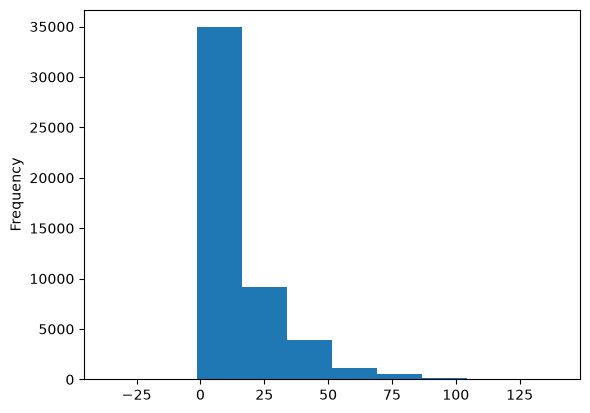

In [14]:
missing_values_df['fare_amount'].plot(kind='hist')

In [15]:
missing_values_df.groupby(missing_values_df['lpep_pickup_datetime'].dt.month,as_index=False).size()

,lpep_pickup_datetime,size
0,1,1836
1,2,2517
2,3,3549
3,4,3188
4,5,3244
5,6,3785
6,7,5185
7,8,4742
8,9,5407
9,10,5015


In [16]:
missing_values_df.groupby(missing_values_df['lpep_pickup_datetime'].dt.to_period('M'),as_index=False).size()

,lpep_pickup_datetime,size
0,2025-01,1836
1,2025-02,2517
2,2025-03,3549
3,2025-04,3188
4,2025-05,3244
5,2025-06,3785
6,2025-07,5185
7,2025-08,4742
8,2025-09,5407
9,2025-10,5015


<Axes: ylabel='Frequency'>

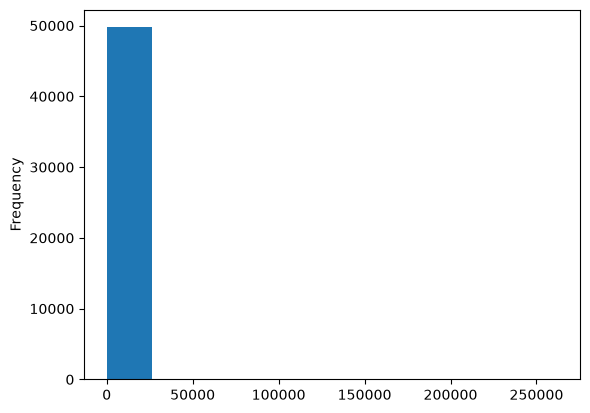

In [17]:
missing_values_df['trip_distance'].plot(kind='hist')

In [18]:
missing_values_df['trip_distance'].describe()

count     49880.000000
mean        191.875749
std        4016.385450
min           0.000000
25%           2.030000
50%           4.280000
75%           8.690000
max      262315.940000
Name: trip_distance, dtype: float64

In [19]:
missing_values_df['trip_distance'].quantile(0.95)

np.float64(17.270499999999956)

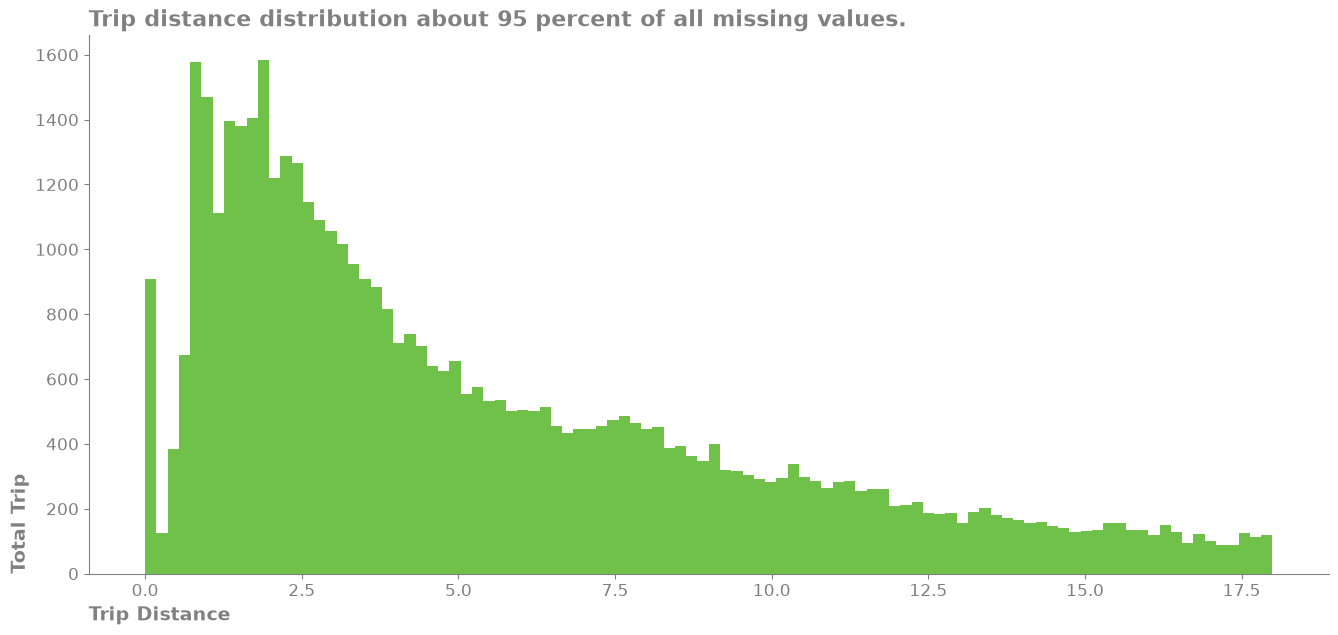

In [20]:
fig , ax = plt.subplots(figsize=(16,7))
plt.hist(missing_values_df.query("trip_distance < 18")['trip_distance'],bins=100,color="#70C14A")
ax.set_title("Trip distance distribution about 95 percent of all missing values.", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color("grey")
ax.set_xlabel("Trip Distance", weight="bold", color="gray", loc="left", fontsize=14)
ax.set_ylabel("Total Trip", weight="bold", color="gray", loc="bottom", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

plt.show()

could not find any algorithm in null values and I decided to keep them because they are less than 10 % of all dataset and can not damage in our insights I dropped it.
I try to find algorithm in missing values with other columns that did not missed now we have to check stations and see why this happen a lot for example in PU 193 and DO 145 why we have missing 529 values in those column and we have to check months we had more or find something new in trip distance distribution to have less missing values in future and have better insights for bussiness

In [21]:
green_taxi_df_copy = green_taxi_df_copy.query("store_and_fwd_flag.notna()")

In [22]:
for col in green_taxi_df_copy.columns :
    pct_missing = ((np.mean(green_taxi_df_copy[col].isna()))*100).round(2)
    print('{} - {}%'.format(col,pct_missing))

VendorID - 0.0%
lpep_pickup_datetime - 0.0%
lpep_dropoff_datetime - 0.0%
store_and_fwd_flag - 0.0%
RatecodeID - 0.0%
PULocationID - 0.0%
DOLocationID - 0.0%
passenger_count - 0.0%
trip_distance - 0.0%
fare_amount - 0.0%
extra - 0.0%
mta_tax - 0.0%
tip_amount - 0.0%
tolls_amount - 0.0%
ehail_fee - 100.0%
improvement_surcharge - 0.0%
total_amount - 0.0%
payment_type - 0.0%
trip_type - 0.01%
congestion_surcharge - 0.0%
cbd_congestion_fee - 0.0%


In [23]:
green_taxi_df_copy.query("trip_type.isna()").head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
1102,1,2025-01-02 08:55:46,2025-01-02 08:55:46,Y,99.0,62,264,0.0,0.0,65.75,...,0.0,0.0,0.0,NaN,0.0,65.75,3.0,NaN,0.0,0.0
4055,1,2025-01-04 08:34:59,2025-01-04 10:29:22,N,99.0,155,155,1.0,0.0,17.50,...,1.5,0.0,0.0,NaN,1.0,19.00,1.0,NaN,0.0,0.0
9975,1,2025-01-08 13:49:51,2025-01-08 13:59:26,N,99.0,83,95,1.0,2.6,0.00,...,0.0,0.0,0.0,NaN,0.0,0.00,1.0,NaN,0.0,0.0
15586,1,2025-01-12 01:34:28,2025-01-12 01:34:28,Y,99.0,78,264,0.0,0.0,62.66,...,0.0,0.0,0.0,NaN,0.0,62.66,3.0,NaN,0.0,0.0
19318,1,2025-01-14 17:33:16,2025-01-14 18:05:31,N,99.0,45,224,1.0,2.0,0.00,...,0.0,0.0,0.0,NaN,0.0,0.00,1.0,NaN,0.0,0.0


In [24]:
green_taxi_df_copy = green_taxi_df_copy.query("trip_type.notna()")

In [25]:
green_taxi_df_copy = green_taxi_df_copy.drop(columns='ehail_fee')

check data quality and validation each column

In [26]:
green_taxi_df_copy.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
count,541448.000000,541448,541448,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000,541448.000000
mean,1.880925,2025-06-27 07:26:05.100860,2025-06-27 07:46:24.243721,1.290266,94.840430,143.752757,1.290368,3.101747,18.489524,0.965183,0.582765,2.768360,0.209397,0.988278,24.723349,1.260784,1.055008,0.873659,0.069828
min,1.000000,2008-12-31 15:13:04,2008-12-31 17:25:57,1.000000,1.000000,1.000000,0.000000,0.000000,-470.600000,-6.000000,-0.500000,-100.000000,-6.940000,-1.000000,-473.100000,1.000000,1.000000,-2.750000,-0.750000
25%,2.000000,2025-03-29 17:07:28.250000,2025-03-29 17:25:11,1.000000,74.000000,75.000000,1.000000,1.180000,10.000000,0.000000,0.500000,0.000000,0.000000,1.000000,14.220000,1.000000,1.000000,0.000000,0.000000
50%,2.000000,2025-06-21 00:30:51,2025-06-21 00:49:24,1.000000,75.000000,141.000000,1.000000,1.900000,14.200000,0.000000,0.500000,2.240000,0.000000,1.000000,19.680000,1.000000,1.000000,0.000000,0.000000
75%,2.000000,2025-09-25 19:32:15.500000,2025-09-25 19:50:06,1.000000,97.000000,234.000000,1.000000,3.200000,20.500000,2.500000,0.500000,4.000000,0.000000,1.000000,28.380000,1.000000,1.000000,2.750000,0.000000
max,2.000000,2026-01-01 21:09:39,2026-01-01 21:49:52,99.000000,265.000000,265.000000,9.000000,84061.550000,1086.600000,12.500000,61.500000,350.000000,108.000000,1.000000,1095.540000,5.000000,2.000000,2.750000,0.750000
std,0.323877,NaN,NaN,2.406727,54.008446,77.533925,0.935519,139.197696,17.960649,1.419139,0.363662,3.664725,1.308784,0.133893,20.275681,0.470107,0.227996,1.280618,0.218005


with these calculation I figured out in some problems in this datasets like in saving dates if look at the date column you see some row saved in 2008 this is wrong because this datasets scrapped at 2025 we have to check it and if it wont damage to our inight remove it and we have some negative amount we have to see this columns to and figured out why this happen and what is the meaning of them is it for cancelled trip or mistake entering data or something else

In [27]:
green_taxi_df_copy.loc[green_taxi_df_copy['lpep_pickup_datetime'].dt.year < 2025]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
9,2,2024-12-31 22:42:13,2024-12-31 22:42:31,N,3.0,74,74,1.0,0.06,23.0,1.0,0.0,0.00,0.00,1.0,25.00,2.0,1.0,0.00,0.0
10,2,2024-12-31 23:01:11,2024-12-31 23:04:29,N,1.0,75,236,1.0,0.66,5.8,1.0,0.5,2.76,0.00,1.0,13.81,1.0,1.0,2.75,0.0
73,2,2024-12-31 23:30:28,2024-12-31 23:35:39,N,1.0,75,151,1.0,1.04,7.9,1.0,0.5,1.50,0.00,1.0,11.90,1.0,1.0,0.00,0.0
251,2,2024-12-31 19:56:14,2024-12-31 20:03:33,N,1.0,82,129,1.0,1.00,8.6,1.0,0.5,2.22,0.00,1.0,13.32,1.0,1.0,0.00,0.0
320,2,2024-12-25 23:13:15,2024-12-25 23:13:17,N,5.0,7,264,3.0,0.00,35.0,0.0,0.0,7.20,0.00,1.0,43.20,1.0,2.0,0.00,0.0
4108,2,2024-12-29 01:23:41,2024-12-29 01:41:08,N,5.0,92,75,6.0,10.15,65.0,0.0,0.0,0.00,6.94,1.0,72.94,2.0,2.0,0.00,0.0
5428,2,2008-12-31 15:13:04,2008-12-31 17:25:57,N,1.0,55,55,1.0,10.17,102.4,0.0,0.5,0.00,0.00,1.0,103.90,2.0,1.0,0.00,0.0


In [28]:
green_taxi_df_copy = green_taxi_df_copy.loc[np.bitwise_not((green_taxi_df_copy['lpep_pickup_datetime'].dt.year < 2025)|(green_taxi_df_copy['lpep_pickup_datetime'].dt.year > 2025))]

because we do not have enough information about these years just 7 rows we could not keep them

In [29]:
green_taxi_df_copy.loc[green_taxi_df_copy['fare_amount'] < 0]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
245,2,2025-01-01 04:20:27,2025-01-01 04:40:48,N,5.0,82,82,1.0,0.00,-113.00,0.0,0.0,0.0,0.0,-1.0,-114.00,4.0,1.0,0.0,0.0
561,2,2025-01-01 15:51:18,2025-01-01 15:51:28,N,1.0,166,166,1.0,0.01,-3.00,0.0,-0.5,0.0,0.0,-1.0,-4.50,3.0,1.0,0.0,0.0
990,2,2025-01-02 01:40:28,2025-01-02 01:41:24,N,5.0,130,130,1.0,0.08,-8.00,0.0,0.0,0.0,0.0,-1.0,-9.00,3.0,2.0,0.0,0.0
1006,2,2025-01-02 03:39:00,2025-01-02 03:39:18,N,5.0,129,82,3.0,0.00,-0.15,0.0,0.0,0.0,0.0,-1.0,-1.15,4.0,2.0,0.0,0.0
1449,2,2025-01-02 12:50:41,2025-01-02 12:50:55,N,1.0,193,193,1.0,0.00,-3.00,0.0,-0.5,0.0,0.0,-1.0,-4.50,3.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41232,2,2025-12-30 21:36:19,2025-12-30 21:36:29,N,5.0,129,129,1.0,0.42,-13.00,0.0,0.0,0.0,0.0,-1.0,-14.00,3.0,2.0,0.0,0.0
41654,2,2025-12-31 13:59:04,2025-12-31 13:59:20,N,1.0,41,41,1.0,0.03,-3.00,0.0,-0.5,0.0,0.0,-1.0,-4.50,4.0,1.0,0.0,0.0
41675,2,2025-12-31 14:09:41,2025-12-31 14:10:02,N,1.0,75,75,2.0,0.00,-3.00,0.0,-0.5,0.0,0.0,-1.0,-4.50,4.0,1.0,0.0,0.0
42131,2,2025-12-31 19:55:27,2025-12-31 19:58:04,N,1.0,97,97,1.0,0.14,-4.40,-2.5,-0.5,0.0,0.0,-1.0,-8.40,4.0,1.0,0.0,0.0


we remove these negative fare amount but we keep them in another df in name of cancelled trip to see insight about them and figured out our questions

In [30]:
cancelled_trip_df = green_taxi_df_copy.loc[green_taxi_df_copy['fare_amount'] < 0]

In [31]:
green_taxi_df_copy = green_taxi_df_copy.loc[green_taxi_df_copy['fare_amount'] > 0]

In [32]:
green_taxi_df_copy.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
count,539215.000000,539215,539215,539215.000000,539215.000000,539215.000000,539215.000000,539215.000000,539215.000000,539215.000000,539215.000000,539215.000000,539215.000000,539215.00000,539215.000000,539215.000000,539215.000000,539215.000000,539215.000000
mean,1.881164,2025-06-27 07:41:10.331443,2025-06-27 08:01:32.205218,1.286713,94.749015,143.831086,1.289680,3.111570,18.604099,0.971461,0.586528,2.779637,0.210225,0.99552,24.870527,1.253127,1.054253,0.877481,0.070112
min,1.000000,2025-01-01 00:01:11,2025-01-01 00:06:59,1.000000,1.000000,1.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.00000,0.010000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,2025-03-29 17:19:17.500000,2025-03-29 17:41:23,1.000000,74.000000,75.000000,1.000000,1.190000,10.000000,0.000000,0.500000,0.000000,0.000000,1.00000,14.280000,1.000000,1.000000,0.000000,0.000000
50%,2.000000,2025-06-21 00:44:36,2025-06-21 01:02:50,1.000000,75.000000,141.000000,1.000000,1.900000,14.200000,0.000000,0.500000,2.280000,0.000000,1.00000,19.680000,1.000000,1.000000,0.000000,0.000000
75%,2.000000,2025-09-25 19:35:56.500000,2025-09-25 19:54:13,1.000000,97.000000,234.000000,1.000000,3.210000,20.500000,2.500000,0.500000,4.000000,0.000000,1.00000,28.440000,1.000000,1.000000,2.750000,0.000000
max,2.000000,2025-12-31 23:59:09,2026-01-01 21:49:52,99.000000,265.000000,265.000000,9.000000,84061.550000,1086.600000,12.500000,61.500000,350.000000,108.000000,1.00000,1095.540000,5.000000,2.000000,2.750000,0.750000
std,0.323595,NaN,NaN,2.397687,53.918983,77.535990,0.934136,139.485429,17.833434,1.417060,0.359224,3.659649,1.311050,0.06544,20.117981,0.453906,0.226516,1.281541,0.218330


In [33]:
green_taxi_df_copy.describe(include='str')

,store_and_fwd_flag
count,539215
unique,2
top,N
freq,537556


# Feature Engineering

In [34]:
green_taxi_df_copy["monthly_pickup"] = green_taxi_df_copy['lpep_pickup_datetime'].dt.strftime("%Y-%m")
green_taxi_df_copy["daily_pickup"] = green_taxi_df_copy['lpep_pickup_datetime'].dt.strftime("%m-%d")
green_taxi_df_copy["month_name_pickup"] = green_taxi_df_copy['lpep_pickup_datetime'].dt.month
green_taxi_df_copy["day_name_pickup"] = green_taxi_df_copy['lpep_pickup_datetime'].dt.day_name()
green_taxi_df_copy["hour_pickup"] = green_taxi_df_copy['lpep_pickup_datetime'].dt.hour

In [35]:
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}
green_taxi_df_copy["season_pickup"] = green_taxi_df_copy['month_name_pickup'].map(season_map)
green_taxi_df_copy["season_pickup"] = pd.Categorical(
    green_taxi_df_copy["season_pickup"],
    categories=["Spring", "Summer", "Autumn", "Winter"]
    ,ordered=True)

In [36]:
green_taxi_df_copy["is_weekend_pickup"] = np.where((green_taxi_df_copy['day_name_pickup']=="Saturday")|(green_taxi_df_copy['day_name_pickup']=="Sunday"),1,0)

In [37]:
green_taxi_df_copy["part_of_day_pickup"] = pd.cut(
    green_taxi_df_copy["hour_pickup"],
    bins=[0, 6, 12, 17, 20, 24],
    labels=["Late Night", "Morning", "Afternoon", "Evening", "Late Evening"],
    right=False,
    include_lowest=True
)

In [38]:
green_taxi_df_copy["trip_duration_minutes"] = ((green_taxi_df_copy['lpep_dropoff_datetime']-green_taxi_df_copy['lpep_pickup_datetime']).dt.total_seconds()/60).round(2)

In [39]:
green_taxi_df_copy["trip_duration_minutes"].describe()

count    539215.000000
mean         20.364556
std          88.910168
min         -48.830000
25%           7.830000
50%          12.130000
75%          18.170000
max        1439.950000
Name: trip_duration_minutes, dtype: float64

In [40]:
(green_taxi_df_copy["trip_duration_minutes"] <= 0).sum()

np.int64(407)

In [41]:
# Validate duration before using it as a denominator.
green_taxi_df_copy.loc[
    green_taxi_df_copy["trip_duration_minutes"] <= 0
]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,cbd_congestion_fee,monthly_pickup,daily_pickup,month_name_pickup,day_name_pickup,hour_pickup,season_pickup,is_weekend_pickup,part_of_day_pickup,trip_duration_minutes
279,1,2025-01-01 05:14:17,2025-01-01 05:14:17,N,1.0,83,264,1.0,0.0,3.0,...,0.0,2025-01,01-01,1,Wednesday,5,Winter,0,Late Night,0.0
280,1,2025-01-01 05:14:21,2025-01-01 05:14:21,N,1.0,83,83,1.0,0.0,3.0,...,0.0,2025-01,01-01,1,Wednesday,5,Winter,0,Late Night,0.0
2450,2,2025-01-03 00:36:28,2025-01-03 00:36:28,N,1.0,173,264,1.0,0.0,3.0,...,0.0,2025-01,01-03,1,Friday,0,Winter,0,Late Night,0.0
2752,1,2025-01-03 10:29:10,2025-01-03 10:29:10,N,1.0,74,264,1.0,0.0,17.7,...,0.0,2025-01,01-03,1,Friday,10,Winter,0,Morning,0.0
3857,2,2025-01-03 22:50:02,2025-01-03 22:50:02,N,1.0,82,264,1.0,0.0,3.0,...,0.0,2025-01,01-03,1,Friday,22,Winter,0,Late Evening,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32997,1,2025-12-22 21:30:30,2025-12-22 21:30:30,Y,1.0,65,264,1.0,0.0,5.1,...,0.0,2025-12,12-22,12,Monday,21,Winter,0,Late Evening,0.0
36561,2,2025-12-26 13:29:24,2025-12-26 13:29:24,N,1.0,264,264,1.0,0.0,3.0,...,0.0,2025-12,12-26,12,Friday,13,Winter,0,Afternoon,0.0
38467,2,2025-12-28 16:55:35,2025-12-28 16:55:35,N,5.0,264,264,1.0,0.0,40.0,...,0.0,2025-12,12-28,12,Sunday,16,Winter,1,Afternoon,0.0
41210,2,2025-12-31 01:12:54,2025-12-31 01:12:54,N,1.0,264,264,1.0,0.0,3.0,...,0.0,2025-12,12-31,12,Wednesday,1,Winter,0,Late Night,0.0


In [42]:
zero_trip_duration = green_taxi_df_copy.loc[
    green_taxi_df_copy["trip_duration_minutes"] <= 0
]

In [43]:
zero_trip_duration.loc[zero_trip_duration['lpep_pickup_datetime']==zero_trip_duration['lpep_dropoff_datetime']]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,cbd_congestion_fee,monthly_pickup,daily_pickup,month_name_pickup,day_name_pickup,hour_pickup,season_pickup,is_weekend_pickup,part_of_day_pickup,trip_duration_minutes
279,1,2025-01-01 05:14:17,2025-01-01 05:14:17,N,1.0,83,264,1.0,0.0,3.0,...,0.0,2025-01,01-01,1,Wednesday,5,Winter,0,Late Night,0.0
280,1,2025-01-01 05:14:21,2025-01-01 05:14:21,N,1.0,83,83,1.0,0.0,3.0,...,0.0,2025-01,01-01,1,Wednesday,5,Winter,0,Late Night,0.0
2450,2,2025-01-03 00:36:28,2025-01-03 00:36:28,N,1.0,173,264,1.0,0.0,3.0,...,0.0,2025-01,01-03,1,Friday,0,Winter,0,Late Night,0.0
2752,1,2025-01-03 10:29:10,2025-01-03 10:29:10,N,1.0,74,264,1.0,0.0,17.7,...,0.0,2025-01,01-03,1,Friday,10,Winter,0,Morning,0.0
3857,2,2025-01-03 22:50:02,2025-01-03 22:50:02,N,1.0,82,264,1.0,0.0,3.0,...,0.0,2025-01,01-03,1,Friday,22,Winter,0,Late Evening,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32997,1,2025-12-22 21:30:30,2025-12-22 21:30:30,Y,1.0,65,264,1.0,0.0,5.1,...,0.0,2025-12,12-22,12,Monday,21,Winter,0,Late Evening,0.0
36561,2,2025-12-26 13:29:24,2025-12-26 13:29:24,N,1.0,264,264,1.0,0.0,3.0,...,0.0,2025-12,12-26,12,Friday,13,Winter,0,Afternoon,0.0
38467,2,2025-12-28 16:55:35,2025-12-28 16:55:35,N,5.0,264,264,1.0,0.0,40.0,...,0.0,2025-12,12-28,12,Sunday,16,Winter,1,Afternoon,0.0
41210,2,2025-12-31 01:12:54,2025-12-31 01:12:54,N,1.0,264,264,1.0,0.0,3.0,...,0.0,2025-12,12-31,12,Wednesday,1,Winter,0,Late Night,0.0


In [44]:
zero_trip_duration.groupby(["PULocationID","DOLocationID"],as_index=False).size().sort_values('size',ascending=False)

,PULocationID,DOLocationID,size
104,264,264,113
32,74,264,21
34,75,264,16
54,130,264,15
79,195,264,12
...,...,...,...
93,244,244,1
102,260,7,1
101,259,259,1
100,258,264,1


<Axes: ylabel='Frequency'>

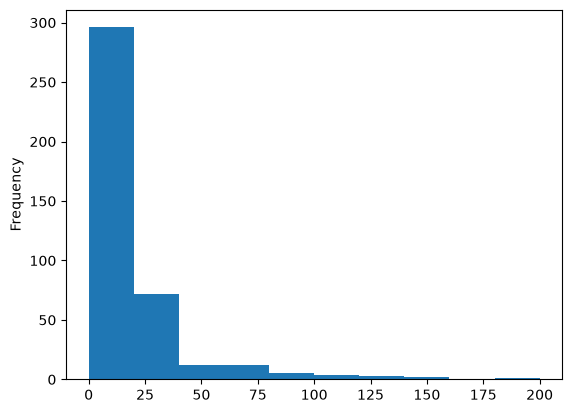

In [45]:
zero_trip_duration['fare_amount'].plot(kind='hist')

In [46]:
zero_trip_duration['trip_distance'].value_counts().reset_index()

,trip_distance,count
0,0.00,369
1,0.01,7
2,1.40,3
3,0.08,2
4,0.22,2
5,0.07,2
6,0.04,2
7,1.20,1
8,1.70,1
9,4.04,1


407 records had zero or non-positive trip duration and were excluded from duration-based analysis after validation.and we discovered that in 264 location ID we have most this issue that have to check it why this happend and why we have pick up and drop off date time the same do they are cancellation trips or just issues in data entering

In [47]:
green_taxi_df_copy = green_taxi_df_copy.loc[
    green_taxi_df_copy["trip_duration_minutes"] > 0
]

In [48]:
green_taxi_df_copy["fare_per_minutes"] = green_taxi_df_copy['fare_amount']/green_taxi_df_copy["trip_duration_minutes"]

In [49]:
green_taxi_df_copy['trip_distance'].describe()

count    538808.000000
mean          3.113762
std         139.538069
min           0.000000
25%           1.200000
50%           1.900000
75%           3.210000
max       84061.550000
Name: trip_distance, dtype: float64

In [50]:
(green_taxi_df_copy["trip_distance"] <= 0).sum()

np.int64(22438)

In [51]:
green_taxi_df_copy.loc[
    green_taxi_df_copy["trip_distance"] <= 0
]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,monthly_pickup,daily_pickup,month_name_pickup,day_name_pickup,hour_pickup,season_pickup,is_weekend_pickup,part_of_day_pickup,trip_duration_minutes,fare_per_minutes
11,2,2025-01-01 00:18:31,2025-01-01 00:18:46,N,5.0,92,92,1.0,0.0,35.0,...,2025-01,01-01,1,Wednesday,0,Winter,0,Late Night,0.25,140.000000
12,1,2025-01-01 00:13:44,2025-01-01 00:27:42,N,1.0,42,159,1.0,0.0,18.5,...,2025-01,01-01,1,Wednesday,0,Winter,0,Late Night,13.97,1.324266
18,2,2025-01-01 00:20:31,2025-01-01 00:20:34,N,5.0,197,197,1.0,0.0,13.0,...,2025-01,01-01,1,Wednesday,0,Winter,0,Late Night,0.05,260.000000
40,2,2025-01-01 00:22:24,2025-01-01 00:26:38,N,1.0,82,82,1.0,0.0,5.8,...,2025-01,01-01,1,Wednesday,0,Winter,0,Late Night,4.23,1.371158
45,2,2025-01-01 00:37:24,2025-01-01 00:40:50,N,5.0,66,66,2.0,0.0,60.0,...,2025-01,01-01,1,Wednesday,0,Winter,0,Late Night,3.43,17.492711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42349,2,2025-12-31 23:26:45,2025-12-31 23:27:27,N,5.0,83,83,1.0,0.0,50.0,...,2025-12,12-31,12,Wednesday,23,Winter,0,Late Evening,0.70,71.428571
42358,2,2025-12-31 23:31:19,2025-12-31 23:31:21,N,5.0,215,215,2.0,0.0,12.0,...,2025-12,12-31,12,Wednesday,23,Winter,0,Late Evening,0.03,400.000000
42368,2,2025-12-31 23:18:15,2025-12-31 23:18:34,N,5.0,7,7,1.0,0.0,243.0,...,2025-12,12-31,12,Wednesday,23,Winter,0,Late Evening,0.32,759.375000
42381,2,2025-12-31 23:36:49,2025-12-31 23:36:56,N,1.0,74,74,1.0,0.0,3.0,...,2025-12,12-31,12,Wednesday,23,Winter,0,Late Evening,0.12,25.000000


In [52]:
zero_trip_distance = green_taxi_df_copy.loc[
    green_taxi_df_copy["trip_distance"] <= 0
]

In [53]:
zero_trip_distance.loc[zero_trip_distance['lpep_pickup_datetime']==zero_trip_distance['lpep_dropoff_datetime']]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,monthly_pickup,daily_pickup,month_name_pickup,day_name_pickup,hour_pickup,season_pickup,is_weekend_pickup,part_of_day_pickup,trip_duration_minutes,fare_per_minutes


In [54]:
zero_trip_distance.groupby(["PULocationID","DOLocationID"],as_index=False).size().sort_values('size',ascending=False)

,PULocationID,DOLocationID,size
4502,264,264,696
1454,74,74,540
2503,129,129,514
1822,82,82,456
2110,95,95,436
...,...,...,...
4487,264,198,1
4488,264,205,1
4489,264,210,1
4490,264,222,1


In [55]:
zero_trip_distance['VendorID'].value_counts().reset_index()

,VendorID,count
0,2,14806
1,1,7632


In [56]:
green_taxi_df_copy = (
    green_taxi_df_copy.loc[
        green_taxi_df_copy["trip_distance"] > 0
    ]
)

trip distance feature had zero and negetive values in there like trip duration so basicly  in transportion data this means we have problem there it can be mistake from data entry , it can be for not saving data correctly from app or drivers and something else that we get data from there so I have to check these values and save in seprate datafarame to solve this problem and discover this problem algorithm 

In [57]:
green_taxi_df_copy["fare_per_distance"] = green_taxi_df_copy['fare_amount']/green_taxi_df_copy["trip_distance"]

# Exploratory Data Analysis

# Univariate Analysis

In [58]:
unuseful_columns = [
    "cbd_congestion_fee",
    "congestion_surcharge",
    "extra",
    "improvement_surcharge",
    "mta_tax",
    "tip_amount",
    "tolls_amount"
]

In [59]:
green_taxi_df_copy = green_taxi_df_copy.drop(columns=unuseful_columns)

In [60]:
vendor_map = {
    1 : "Creative Mobile Technologies, LLC",
    2 : "Curb Mobility, LLC",
    6 : "Myle Technologies Inc"
}

In [61]:
vendor_id_dist = (
    green_taxi_df_copy['VendorID']
    .value_counts(normalize=True)
    .mul(100)
    .to_frame()
    .reset_index()
    .sort_values("proportion")
    .assign(
        vendor_name = lambda x : x['VendorID'].map(vendor_map)
    )
)

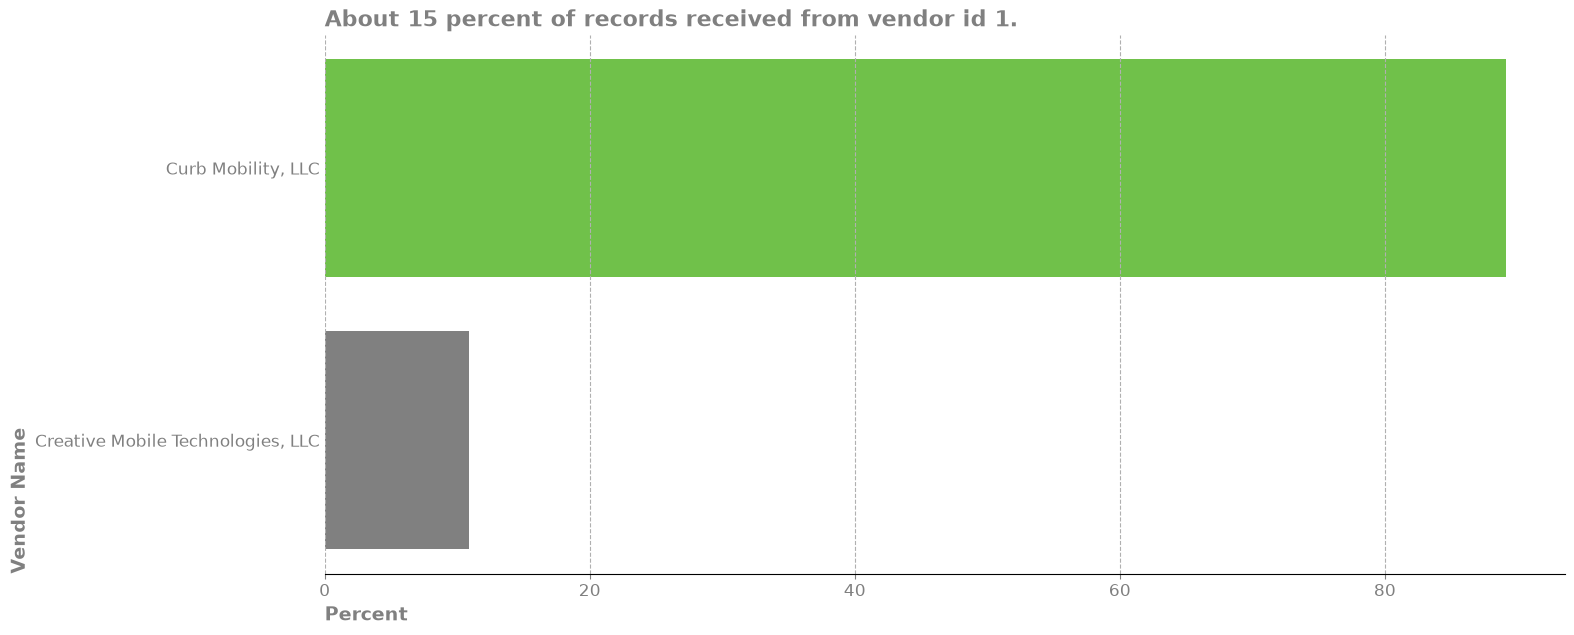

In [62]:
fig , ax = plt.subplots(figsize=(16,7))
plt.barh(vendor_id_dist['vendor_name'],vendor_id_dist['proportion'],color=np.where(vendor_id_dist['VendorID']==2,"#70C14A","grey"))
ax.set_title("About 15 percent of records received from vendor id 1.", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)
ax.spines[['left','right','top']].set_visible(False)
ax.set_xlabel("Percent", weight="bold", color="gray", loc="left", fontsize=14)
ax.set_ylabel("Vendor Name", weight="bold", color="gray", loc="bottom", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")
ax.tick_params(axis="y", which="major", length=0)

ax.grid(axis="x", linestyle="dashed")

plt.show()

automaticly vendor id 6 removed from dataset when we decided to remove null values and drop not quality data like missing values and mistake values and ...

In [63]:
green_taxi_df_copy['store_and_fwd_flag'].value_counts().to_frame().reset_index().sort_values("count")

,store_and_fwd_flag,count
1,Y,1441
0,N,514929


more than 99 % of all records did not save in car storage before forward to our server

In [64]:
rate_code_map = {
    1 : "Standard rate",
    2 : "JFK",
    3 : "Newark",
    4 : "Nassau or Westchester",
    5 : "Negotiated fare",
    6 : "Group ride",
    99 : "Null/Unknown"
}

In [65]:
rate_code_id = (
    green_taxi_df_copy['RatecodeID']
    .value_counts()
    .to_frame()
    .reset_index()
    .sort_values("count")
    .assign(
        rate_code_name=lambda x : x['RatecodeID'].map(rate_code_map)
        )
    .assign(
        proportion= lambda x : (x['count']/x['count'].sum()).mul(100)
    )
)

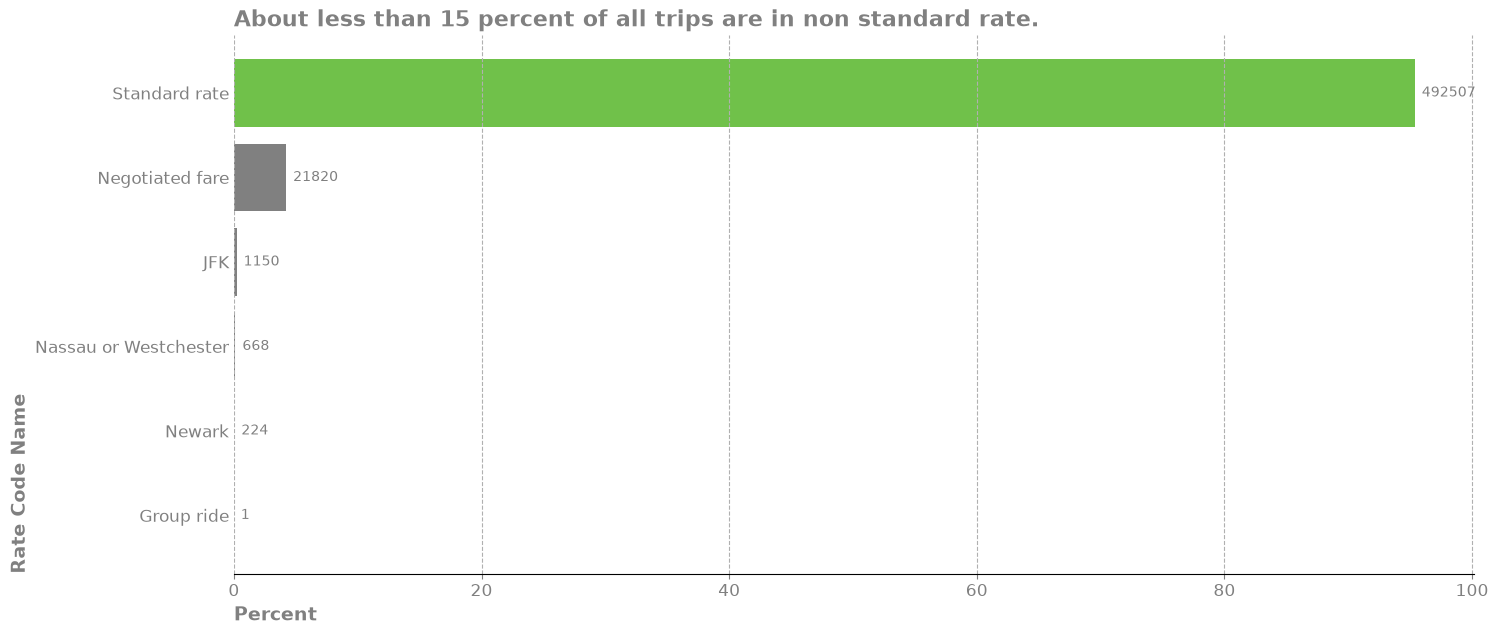

In [66]:
fig , ax = plt.subplots(figsize=(16,7))
bar = plt.barh(rate_code_id['rate_code_name'],rate_code_id['proportion'],color=np.where(rate_code_id['proportion'].gt(75),"#70C14A","grey"))
plt.bar_label(bar,label_type='edge',labels=rate_code_id['count'],padding=5,color='grey')
ax.set_title("About less than 15 percent of all trips are in non standard rate.", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)
ax.spines[['left','right','top']].set_visible(False)
ax.set_xlabel("Percent", weight="bold", color="gray", loc="left", fontsize=14)
ax.set_ylabel("Rate Code Name", weight="bold", color="gray", loc="bottom", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")
ax.tick_params(axis="y", which="major", length=0)

ax.grid(axis="x", linestyle="dashed")

plt.show()

In [67]:
passenger_count_status = (
    green_taxi_df_copy['passenger_count']
    .value_counts()
    .to_frame()
    .reset_index()
    .sort_values("passenger_count")
    .assign(
        proportion = lambda x : (x['count']/x['count'].sum()).mul(100)
        )
)

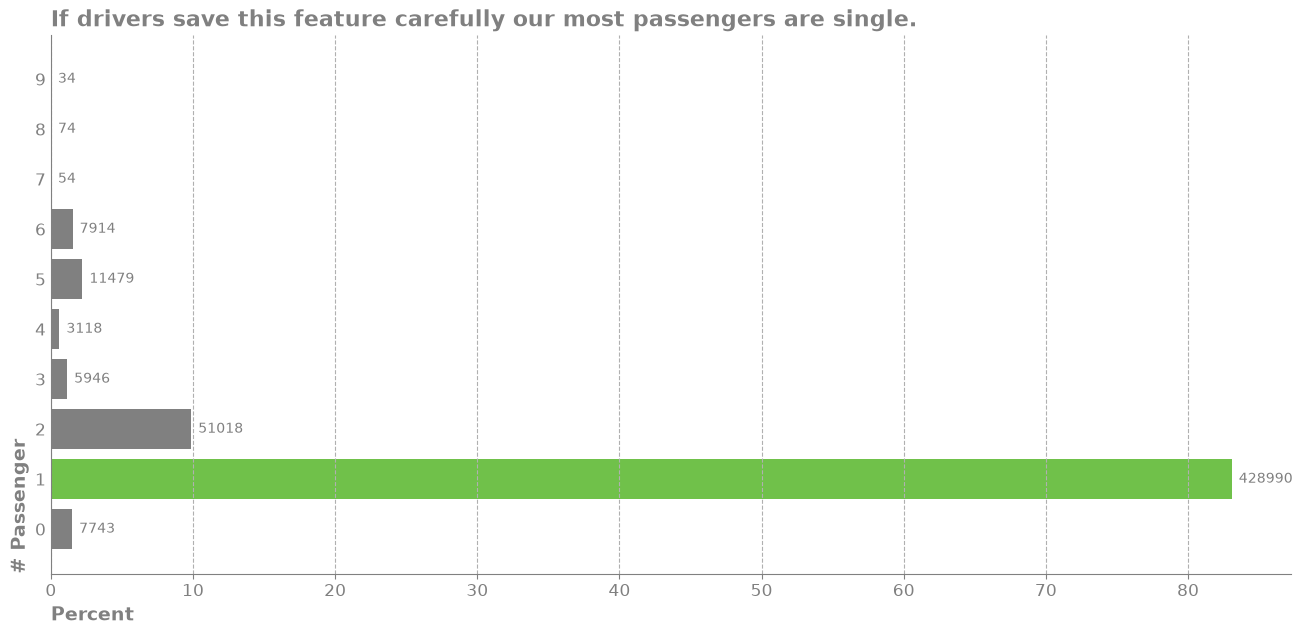

In [68]:
fig , ax = plt.subplots(figsize=(16,7))
bar = plt.barh(
    passenger_count_status['passenger_count'].astype("Int64").astype(str)
    ,passenger_count_status['proportion']
    ,color = np.where(passenger_count_status['passenger_count'] == 1 , "#70C14A" , "grey")
)

plt.bar_label(
    bar
    ,label_type='edge'
    ,labels=passenger_count_status['count']
    ,padding=5
    ,color='grey'
)

ax.set_title("If drivers save this feature carefully our most passengers are single.", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color("grey")

ax.set_xlabel("Percent", weight="bold", color="gray", loc="left", fontsize=14)
ax.set_ylabel("# Passenger", weight="bold", color="gray", loc="bottom", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")
ax.tick_params(axis="y", which="major", length=0)

ax.grid(axis="x", linestyle="dashed")

plt.show()

zero passenger we have to find out what is the meaning of this the first and then why it happend and then how should we behave with this values now I have limitaion that I do not know what is the meaning of 0 passenger is this cancelled trip or mistake in data entry or mistake from servers and ....

In [69]:
green_taxi_df_copy['fare_amount'].describe()

count    516370.000000
mean         18.336811
std          16.433252
min           0.010000
25%          10.000000
50%          14.200000
75%          20.500000
max        1086.600000
Name: fare_amount, dtype: float64

In [70]:
green_taxi_df_copy['fare_amount'].quantile(0.99)

np.float64(82.1)

<Axes: ylabel='Frequency'>

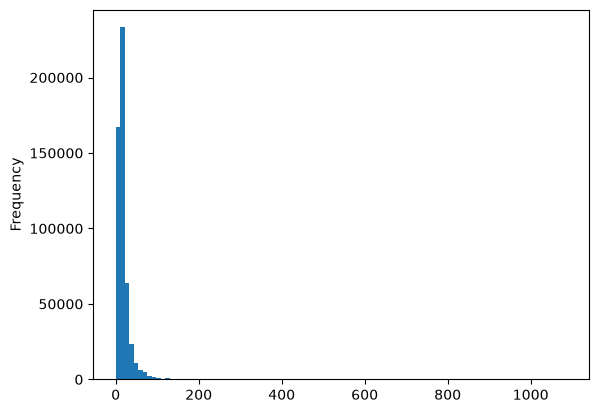

In [71]:
green_taxi_df_copy['fare_amount'].plot(kind='hist',bins=100)

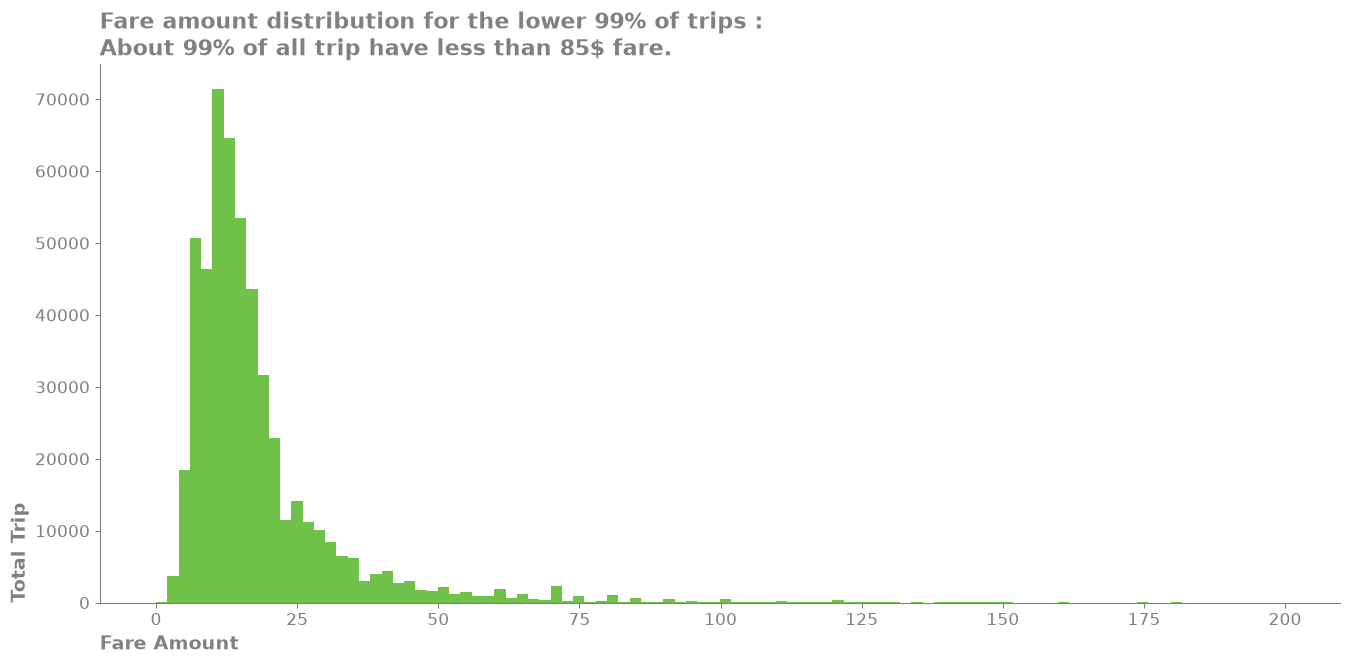

In [72]:
fig , ax = plt.subplots(figsize=(16,7))
plt.hist(green_taxi_df_copy.query("fare_amount < 200")['fare_amount'],bins=100,color="#70C14A")
ax.set_title("Fare amount distribution for the lower 99% of trips :\nAbout 99% of all trip have less than 85$ fare.", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color("grey")
ax.set_xlabel("Fare Amount", weight="bold", color="gray", loc="left", fontsize=14)
ax.set_ylabel("Total Trip", weight="bold", color="gray", loc="bottom", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

plt.show()

this is shows that our most passengers used us for short trip with low fare 

In [73]:
payment_type_map = {
    0 : "Flex Fare trip",
    1 : "Credit card",
    2 : "Cash",
    3 : "No charge",
    4 : "Dispute",
    5 : "Unknown",
    6 : "Voided trip"
}

In [74]:
payment_type_status = (
    green_taxi_df_copy['payment_type']
    .value_counts(normalize=True)
    .mul(100)
    .to_frame()
    .reset_index()
    .sort_values("proportion")
    .assign(
        payment_type_name=lambda x : x['payment_type'].map(payment_type_map)
        )
)

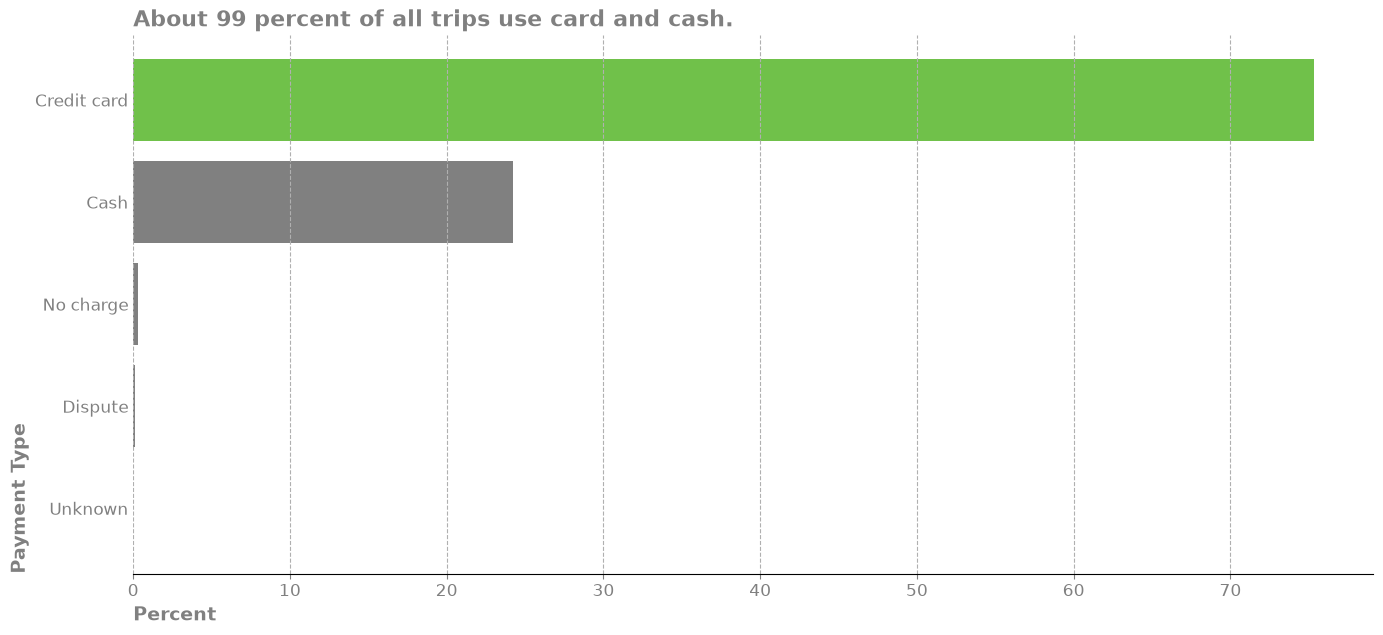

In [75]:
fig , ax = plt.subplots(figsize=(16,7))
bar = plt.barh(payment_type_status['payment_type_name'],payment_type_status['proportion'],color=np.where(payment_type_status['proportion'].gt(75),"#70C14A","grey"))
ax.set_title("About 99 percent of all trips use card and cash.", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)
ax.spines[['left','right','top']].set_visible(False)
ax.set_xlabel("Percent", weight="bold", color="gray", loc="left", fontsize=14)
ax.set_ylabel("Payment Type", weight="bold", color="gray", loc="bottom", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")
ax.tick_params(axis="y", which="major", length=0)

ax.grid(axis="x", linestyle="dashed")

plt.show()

In [76]:
green_taxi_df_copy['trip_type'].value_counts().to_frame().reset_index()

,trip_type,count
0,1.0,496024
1,2.0,20346


1 is related to street hail and 2 is for dispatch

In [77]:
green_taxi_df_copy['store_and_fwd_flag'].value_counts().to_frame().reset_index()

,store_and_fwd_flag,count
0,N,514929
1,Y,1441


In [78]:
green_taxi_df_copy['trip_distance'].describe()

count    516370.000000
mean          3.249065
std         142.535992
min           0.010000
25%           1.280000
50%           1.980000
75%           3.320000
max       84061.550000
Name: trip_distance, dtype: float64

<Axes: >

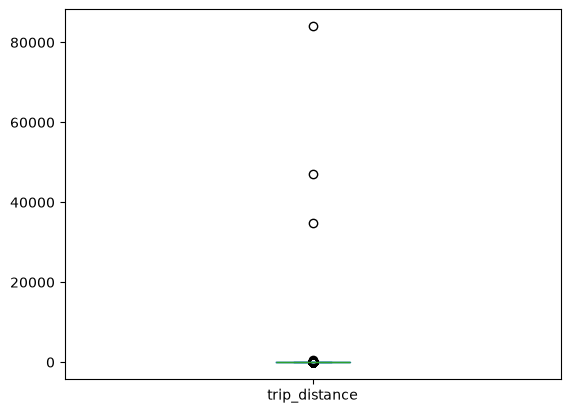

In [79]:
green_taxi_df_copy['trip_distance'].plot(kind='box')

In [80]:
green_taxi_df_copy.assign(distance_zscore = lambda df : stats.zscore(df['trip_distance'],nan_policy='omit')).query("distance_zscore > 3 or distance_zscore < -3")

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,month_name_pickup,day_name_pickup,hour_pickup,season_pickup,is_weekend_pickup,part_of_day_pickup,trip_duration_minutes,fare_per_minutes,fare_per_distance,distance_zscore
6076,2,2025-02-05 08:48:27,2025-02-05 09:12:31,N,5.0,75,82,1.0,84061.55,33.95,...,2,Wednesday,8,Winter,0,Morning,24.07,1.410469,0.000404,589.734432
15079,2,2025-03-10 19:46:58,2025-03-10 20:10:52,N,5.0,82,236,1.0,47081.73,31.99,...,3,Monday,19,Spring,0,Evening,23.90,1.338494,0.000679,330.292201
37072,2,2025-03-24 21:07:42,2025-03-24 21:30:30,N,5.0,82,236,1.0,523.76,32.50,...,3,Monday,21,Spring,0,Late Evening,22.80,1.425439,0.062051,3.651789
42600,2,2025-09-30 12:17:21,2025-09-30 12:17:44,N,5.0,95,95,1.0,34689.73,12.00,...,9,Tuesday,12,Autumn,0,Afternoon,0.38,31.578947,0.000346,243.352672


In [81]:
q1_trip_distance = green_taxi_df_copy['trip_distance'].quantile(0.25)
q3_trip_distance = green_taxi_df_copy['trip_distance'].quantile(0.75)

interquartile_range = q3_trip_distance - q1_trip_distance

lower_bound = q1_trip_distance - 1.5 * interquartile_range
upper_bound = q3_trip_distance + 1.5 * interquartile_range

In [82]:
distance_outlier = (
    green_taxi_df_copy
    .assign(distance_iqr = lambda df : 
        np.where((df['trip_distance'].gt(upper_bound))|(df['trip_distance'].lt(lower_bound)),'outlier','normal'))
    .query("distance_iqr == 'outlier'")
)
distance_normal = (
    green_taxi_df_copy
    .assign(distance_iqr = lambda df : 
        np.where((df['trip_distance'].gt(upper_bound))|(df['trip_distance'].lt(lower_bound)),'outlier','normal'))
    .query("distance_iqr == 'normal'")
)

In [83]:
distance_outlier.shape[0]

50421

<Axes: >

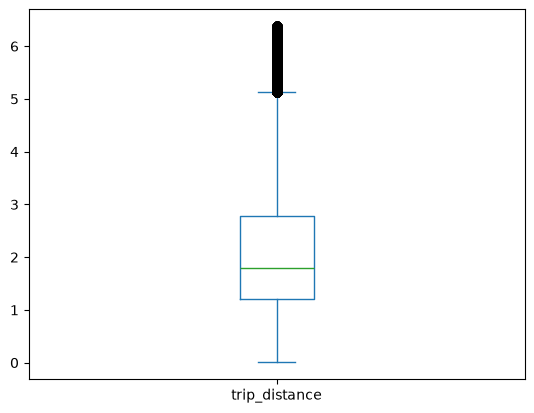

In [84]:
distance_normal['trip_distance'].plot(kind='box')

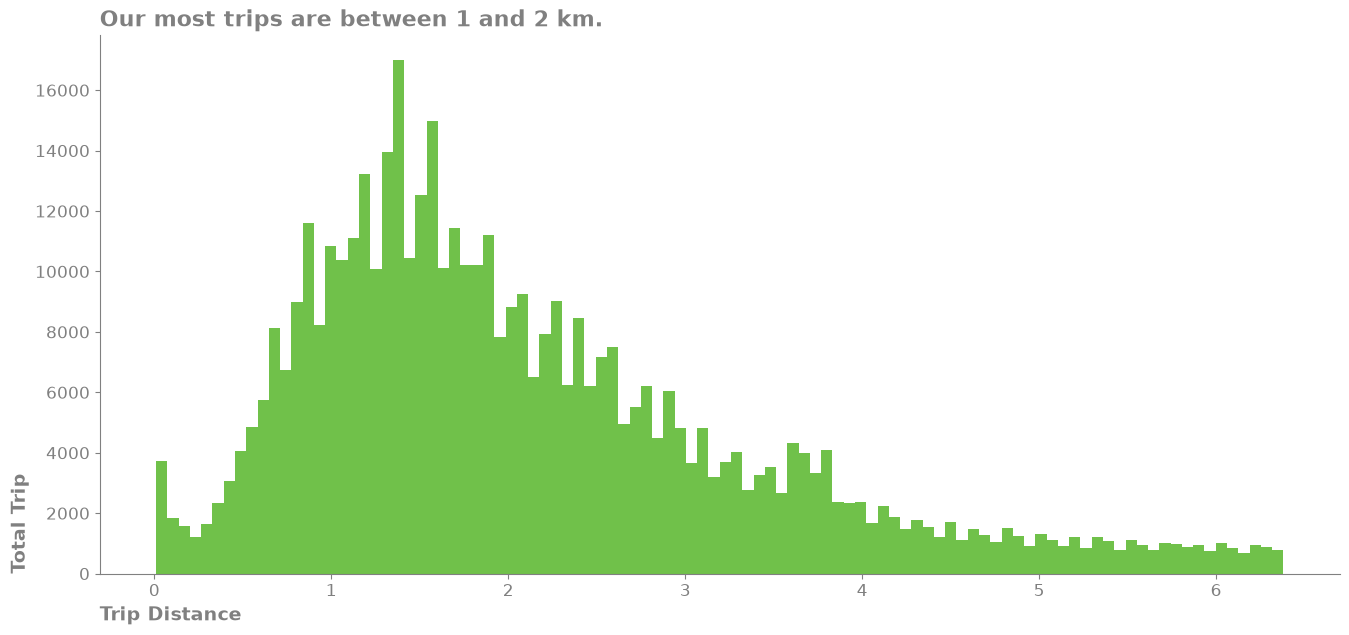

In [85]:
fig , ax = plt.subplots(figsize=(16,7))
plt.hist(distance_normal['trip_distance'],bins=100,color="#70C14A")
ax.set_title("Our most trips are between 1 and 2 km.", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color("grey")
ax.set_xlabel("Trip Distance", weight="bold", color="gray", loc="left", fontsize=14)
ax.set_ylabel("Total Trip", weight="bold", color="gray", loc="bottom", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

plt.show()

attention : in this plot I rather filter outlier trip distance to see this feature distribution better to find out or discover some insights from it and outliers detect from IQR formulas and before that I tried to filter them with zscore way but in that way could not find any values and for complete our insight I will plot outliers sepretly

In [86]:
distance_outlier['trip_distance'].describe()

count    50421.000000
mean        13.606124
std        455.998164
min          6.390000
25%          7.200000
50%          8.640000
75%         11.480000
max      84061.550000
Name: trip_distance, dtype: float64

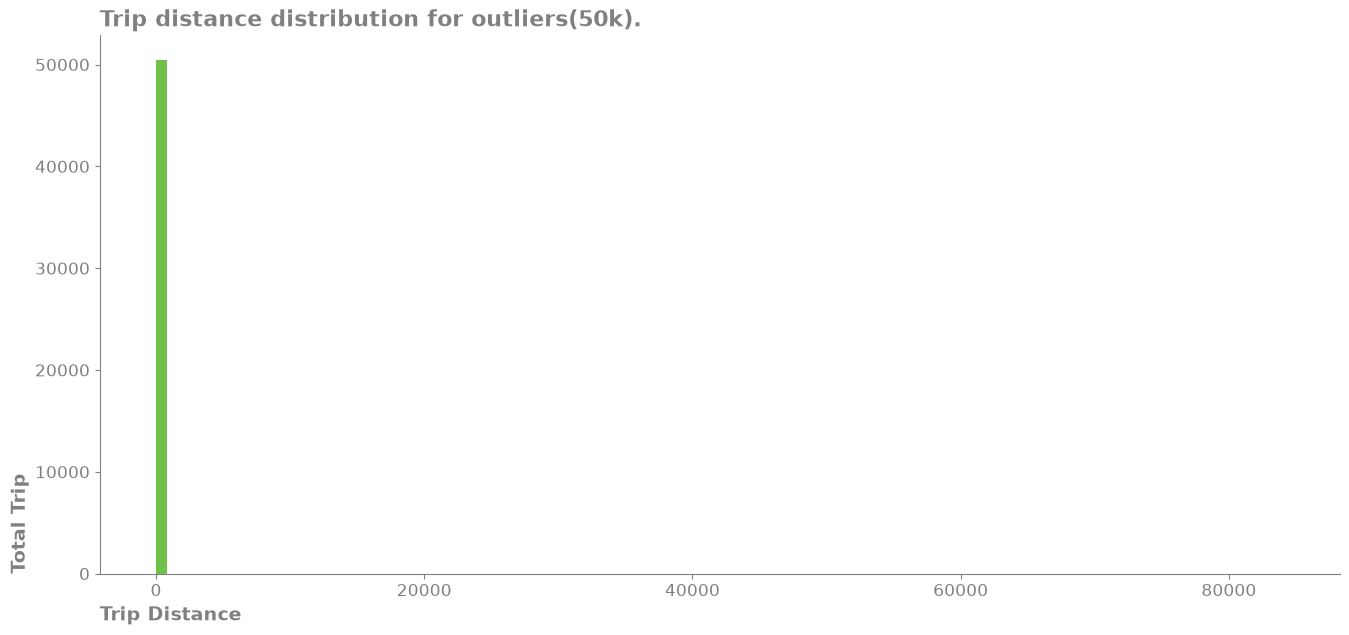

In [87]:
fig , ax = plt.subplots(figsize=(16,7))
plt.hist(distance_outlier['trip_distance'],bins=100,color="#70C14A")
ax.set_title("Trip distance distribution for outliers(50k).", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color("grey")
ax.set_xlabel("Trip Distance", weight="bold", color="gray", loc="left", fontsize=14)
ax.set_ylabel("Total Trip", weight="bold", color="gray", loc="bottom", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

plt.show()

for our maximum values that has too far from our normal trip we could not see this plot and we have to check them is it true or not 

In [88]:
green_taxi_df_copy['trip_duration_minutes'].describe()

count    516370.000000
mean         20.734001
std          90.234409
min           0.020000
25%           8.120000
50%          12.280000
75%          18.220000
max        1439.880000
Name: trip_duration_minutes, dtype: float64

<Axes: >

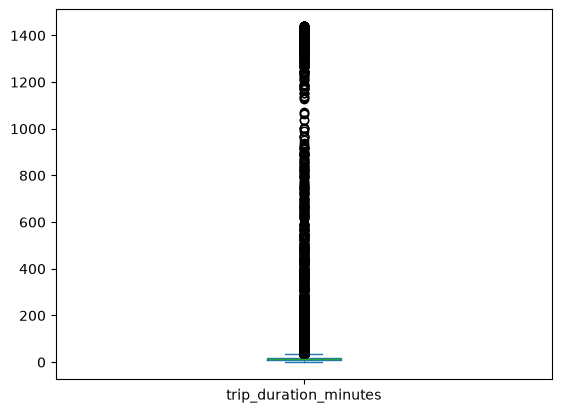

In [89]:
green_taxi_df_copy['trip_duration_minutes'].plot(kind='box')

In [90]:
green_taxi_df_copy.assign(trip_duration_zscore = lambda df : stats.zscore(df['trip_duration_minutes'])).query("trip_duration_zscore > 3 or trip_duration_zscore < -3")

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,month_name_pickup,day_name_pickup,hour_pickup,season_pickup,is_weekend_pickup,part_of_day_pickup,trip_duration_minutes,fare_per_minutes,fare_per_distance,trip_duration_zscore
97,2,2025-01-01 01:12:34,2025-01-02 00:47:47,N,1.0,129,173,1.0,0.68,7.2,...,1,Wednesday,1,Winter,0,Late Night,1415.22,0.005088,10.588235,15.454053
434,2,2025-01-01 12:10:09,2025-01-02 11:19:12,N,1.0,74,236,1.0,2.07,11.4,...,1,Wednesday,12,Winter,0,Afternoon,1389.05,0.008207,5.507246,15.164030
502,2,2025-01-01 14:24:56,2025-01-02 13:41:19,N,1.0,74,239,1.0,3.51,18.4,...,1,Wednesday,14,Winter,0,Afternoon,1396.38,0.013177,5.242165,15.245263
521,2,2025-01-01 14:51:31,2025-01-02 00:00:00,N,1.0,74,262,1.0,2.96,16.3,...,1,Wednesday,14,Winter,0,Afternoon,548.48,0.029718,5.506757,5.848617
791,2,2025-01-01 18:05:28,2025-01-02 17:08:35,N,1.0,134,135,1.0,0.86,7.2,...,1,Wednesday,18,Winter,0,Evening,1383.12,0.005206,8.372093,15.098313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41250,2,2025-12-31 06:57:11,2025-12-31 12:43:28,N,1.0,82,82,1.0,32.19,294.9,...,12,Wednesday,6,Winter,0,Morning,346.28,0.851623,9.161230,3.607785
41757,2,2025-12-31 15:14:22,2026-01-01 14:13:49,N,1.0,65,61,1.0,2.91,19.8,...,12,Wednesday,15,Winter,0,Afternoon,1379.45,0.014354,6.804124,15.057641
41817,2,2025-12-31 16:10:05,2026-01-01 13:21:44,N,1.0,95,121,1.0,2.60,14.9,...,12,Wednesday,16,Winter,0,Afternoon,1271.65,0.011717,5.730769,13.862973
41830,2,2025-12-31 11:39:21,2026-01-01 11:10:28,N,1.0,112,82,1.0,5.02,29.6,...,12,Wednesday,11,Winter,0,Morning,1411.12,0.020976,5.896414,15.408616


In [91]:
q1_trip_duration = green_taxi_df_copy['trip_duration_minutes'].quantile(0.25)
q3_trip_duration = green_taxi_df_copy['trip_duration_minutes'].quantile(0.75)

interquartile_range = q3_trip_duration - q1_trip_duration

lower_bound = q1_trip_duration - 1.5 * interquartile_range
upper_bound = q3_trip_duration + 1.5 * interquartile_range

In [92]:
duration_outlier = (
    green_taxi_df_copy
    .assign(duration_iqr = lambda df : 
        np.where((df['trip_duration_minutes'].gt(upper_bound))|(df['trip_duration_minutes'].lt(lower_bound)),'outlier','normal'))
    .query("duration_iqr == 'outlier'")
)
duration_normal = (
    green_taxi_df_copy
    .assign(duration_iqr = lambda df : 
        np.where((df['trip_duration_minutes'].gt(upper_bound))|(df['trip_duration_minutes'].lt(lower_bound)),'outlier','normal'))
    .query("duration_iqr == 'normal'")
)

In [93]:
duration_outlier.shape[0]

28255

<Axes: >

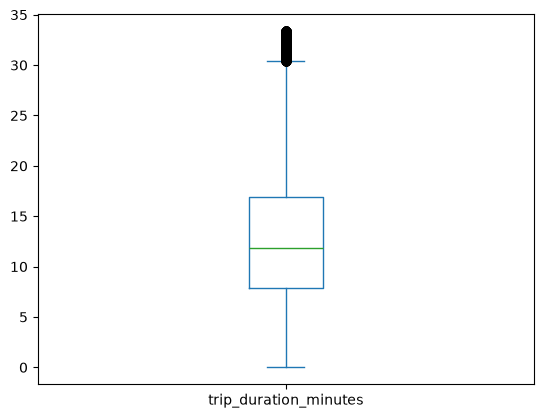

In [94]:
duration_normal['trip_duration_minutes'].plot(kind='box')

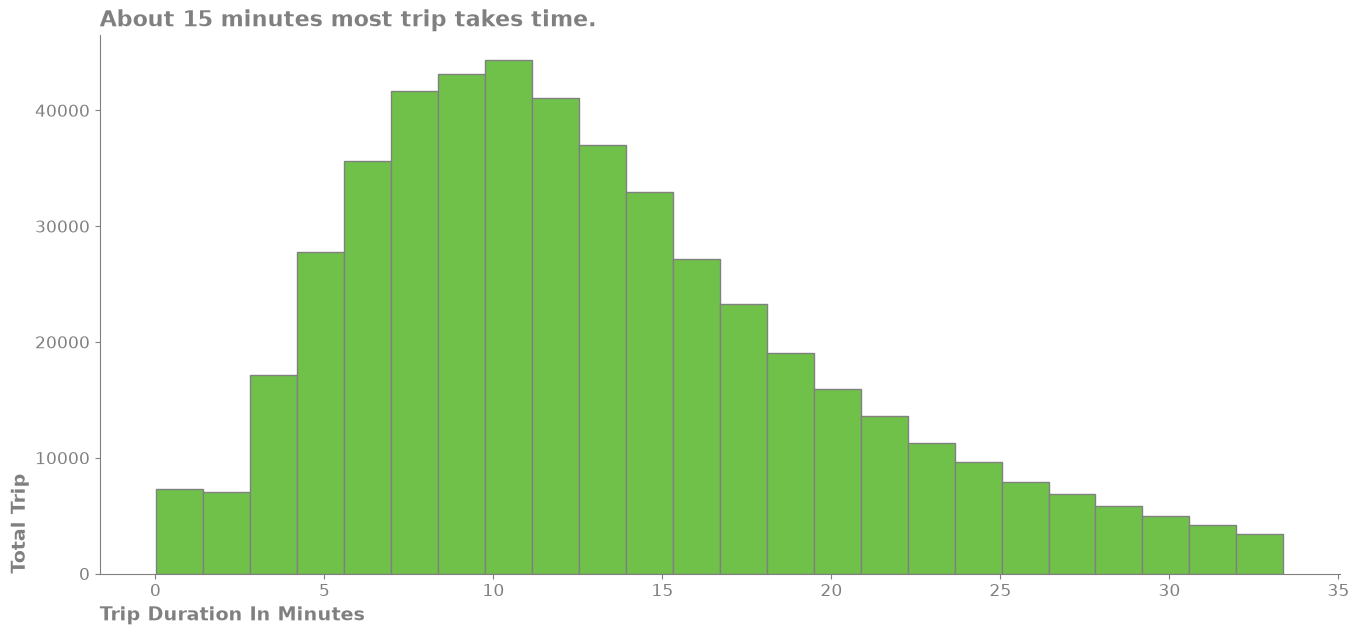

In [95]:
fig , ax = plt.subplots(figsize=(16,7))
plt.hist(duration_normal['trip_duration_minutes'],bins=24,color="#70C14A",edgecolor='grey')
ax.set_title("About 15 minutes most trip takes time.", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color("grey")
ax.set_xlabel("Trip Duration In Minutes", weight="bold", color="gray", loc="left", fontsize=14)
ax.set_ylabel("Total Trip", weight="bold", color="gray", loc="bottom", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

plt.show()

I did this like trip distance filter outlier values for better insight

In [96]:
hourly_trip = (
    green_taxi_df_copy['hour_pickup']
    .value_counts()
    .to_frame()
    .reset_index()
    .sort_values('hour_pickup')
    .assign(hour_count_zscore = lambda df : stats.zscore(df['count'])
            ,hour_color=lambda df : np.where(df['hour_count_zscore'].gt(1),'#70C14A',"#808080"))
)

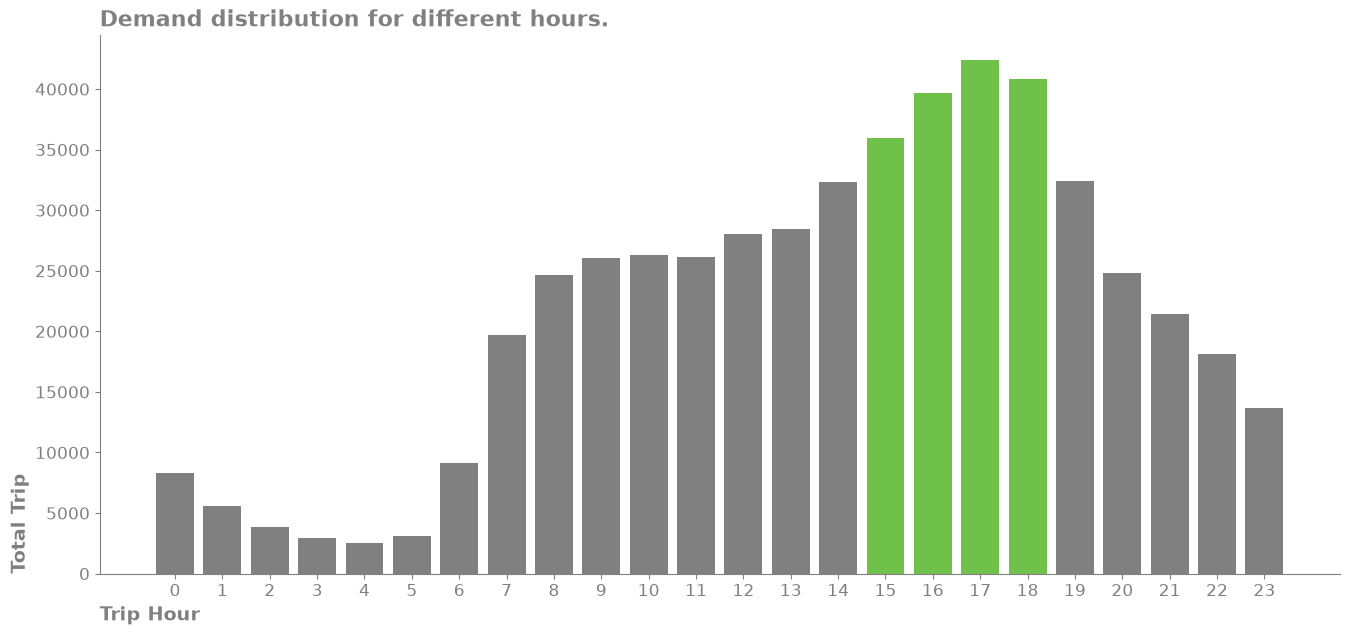

In [97]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.bar(hourly_trip['hour_pickup'],
       hourly_trip['count'],
       color=hourly_trip['hour_color'])


ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.tick_params(axis="both", colors="gray", labelsize=12)

ax.set_title("Demand distribution for different hours.", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)
ax.set_xlabel("Trip Hour", fontsize=14, color="gray", loc="left", weight="bold")
ax.set_ylabel("Total Trip", fontsize=14, color="gray", loc="bottom", weight="bold")

ax.set_xticks(range(0, 24))
plt.show()

### Business Insights — Hourly Trip Volume

- Trip demand is not evenly distributed throughout the day. Certain hours account for a noticeably larger share of total trips, indicating clear hourly demand patterns.
- The highlighted hours represent periods with **above-average trip volume** compared with the overall hourly distribution.
- These high-volume periods may require increased driver availability to reduce passenger waiting time and maintain service reliability.
- Hourly demand information can support more effective driver scheduling, shift planning, and fleet allocation.
- Driver incentives can be concentrated around above-average demand hours to encourage sufficient supply during high-volume periods.
- Lower-volume hours may provide opportunities to reduce excess supply, conduct vehicle maintenance, or schedule driver breaks without significantly affecting service capacity.
- The hourly trip-volume pattern can also support demand forecasting and operational planning for similar time periods in the future.

> **Business Takeaway:**  
> Hourly trip volume should be used as a basis for demand-aware workforce planning. Allocating more drivers during above-average demand hours can help improve operational efficiency and maintain service quality.

In [98]:
daily_trip_count = (
    green_taxi_df_copy['daily_pickup']
        .value_counts()
        .to_frame()
        .reset_index()
        .sort_values('daily_pickup')    
        .assign(daily_count_zscore = lambda df : stats.zscore(df['count'])
                ,daily_color=lambda df : np.where((df['daily_count_zscore'].gt(1))|(df['daily_count_zscore'].lt(-1)),'#70C14A',"#808080"))
)

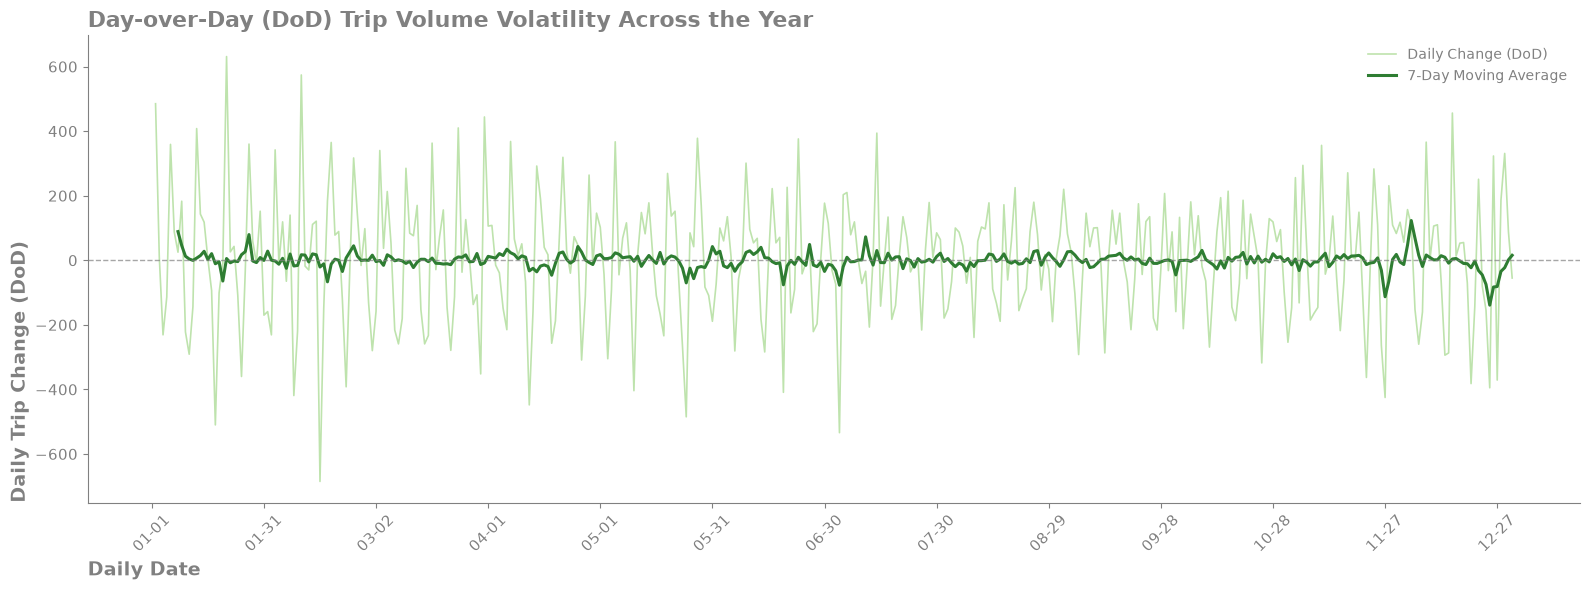

In [99]:
daily_trip_count['daily_growth'] = daily_trip_count['count'].diff()
daily_trip_count['rolling_7d'] = daily_trip_count['daily_growth'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    daily_trip_count['daily_pickup'],
    daily_trip_count['daily_growth'],
    color='#70C14A',
    alpha=0.45,
    linewidth=1.2,
    label='Daily Change (DoD)'
)

ax.plot(
    daily_trip_count['daily_pickup'],
    daily_trip_count['rolling_7d'],
    color='#2E7D32',
    linewidth=2.2,
    label='7-Day Moving Average'
)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

plt.xticks(range(0, len(daily_trip_count['daily_pickup']), 30), rotation=45)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')
plt.tick_params(axis='both', colors='gray', labelsize=11)

plt.ylabel('Daily Trip Change (DoD)',  fontsize=14, color="gray", loc="bottom", weight="bold")
plt.xlabel('Daily Date',  fontsize=14, color="gray", loc="left", weight="bold")
plt.legend(frameon=False, loc='upper right', labelcolor='gray')

plt.title('Day-over-Day (DoD) Trip Volume Volatility Across the Year', 
            loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)

plt.tight_layout()
plt.show()


###  Business Insights — Daily Demand Volatility & Seasonality

- **High-Frequency Day-over-Day Fluctuations:** The fleet experiences substantial day-to-day demand swings (ranging up to ±400 to ±600 trips), primarily driven by structural weekday-versus-weekend operational rhythms.
- **Mid-Year Stabilization:** During the summer months (July–September), daily demand variance narrows noticeably, reflecting a more predictable and stable baseline demand compared to earlier and later quarters.
- **Extreme Outlier Events:** Sharp downward spikes (e.g., mid-February, early June) represent isolated operational shocks or localized external disruptions (such as extreme weather or holiday disruptions) that require retrospective operational logging.
- **Capacity & Buffer Management:** High day-over-day volatility highlights the risk of static driver scheduling. Rigid supply models will inevitably cause either driver undersupply on peak days or idle capacity on trough days.

> **Business Takeaway:**  
> Day-to-day fleet scheduling should incorporate dynamic capacity buffers and rolling 7-day demand forecasts rather than static day-by-day headcount, mitigating driver idle time during predictable intra-week drops.

In [100]:
monthly_trip_count = (
    green_taxi_df_copy['monthly_pickup']
        .value_counts()
        .to_frame()
        .reset_index()
        .sort_values('monthly_pickup')    
        .assign(monthly_count_zscore = lambda df : stats.zscore(df['count']),monthly_color=lambda df : np.where(df['monthly_count_zscore'].gt(1),'#70C14A','#808080')))

monthly_trip_count

,monthly_pickup,count,monthly_count_zscore,monthly_color
4,2025-01,43716,0.259759,#808080
7,2025-02,41674,-0.514400,#808080
2,2025-03,45166,0.809480,#808080
1,2025-04,45970,1.114290,#70C14A
0,2025-05,49288,2.372203,#70C14A
3,2025-06,43752,0.273407,#808080
8,2025-07,41482,-0.587190,#808080
10,2025-08,40008,-1.146010,#808080
6,2025-09,41994,-0.393082,#808080
5,2025-10,42765,-0.100782,#808080


In [101]:
monthly_trip_count['monthly_growth'] = monthly_trip_count['count'].diff()
monthly_trip_count['rolling_3_month'] = monthly_trip_count['monthly_growth'].rolling(3).mean()

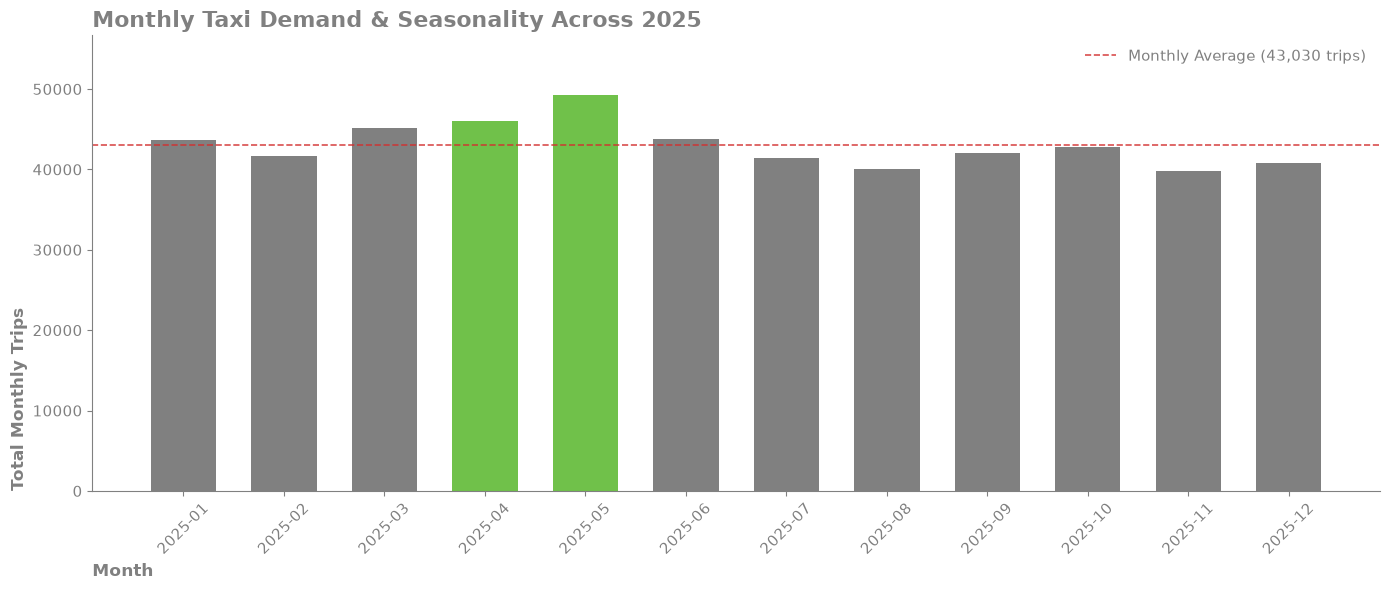

In [102]:
monthly_trip_count = monthly_trip_count.sort_values('monthly_pickup').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))

barplot_rect = ax.bar(
    monthly_trip_count['monthly_pickup'],
    monthly_trip_count['count'],
    color=monthly_trip_count['monthly_color'],
    width=0.65,
    edgecolor='none'
)


mean_val = monthly_trip_count['count'].mean()
ax.axhline(mean_val, color='#D32F2F', linestyle='--', linewidth=1.2, alpha=0.85, 
           label=f'Monthly Average ({int(mean_val):,} trips)')



ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')
plt.tick_params(axis='both', colors='gray', labelsize=11)
plt.xticks(rotation=45)

ax.set_ylim(0, monthly_trip_count['count'].max() * 1.15)

plt.ylabel('Total Monthly Trips',    
            loc="bottom", 
             weight="bold", 
             color="gray",
             fontsize=12)
plt.xlabel('Month',            
           loc="left", 
             weight="bold", 
             color="gray",
             fontsize=12)
plt.legend(frameon=False, loc='upper right', labelcolor='gray', fontsize=11)

plt.title('Monthly Taxi Demand & Seasonality Across 2025', 
            loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)

plt.tight_layout()
plt.show()


# Bivariate Analysis 

In [103]:
hourly_duration_trip_mean = (
    green_taxi_df_copy
    .groupby("hour_pickup",as_index=False)
    .agg(duration_mean=('trip_duration_minutes','mean'))
    .assign(duration_zscore = lambda df : stats.zscore(df['duration_mean'])
            ,hour_color = lambda df : np.where(df['duration_zscore'].gt(1),'#70C14A','#808080')
            ,duration_mean = lambda df : np.round(df['duration_mean'],0))
)

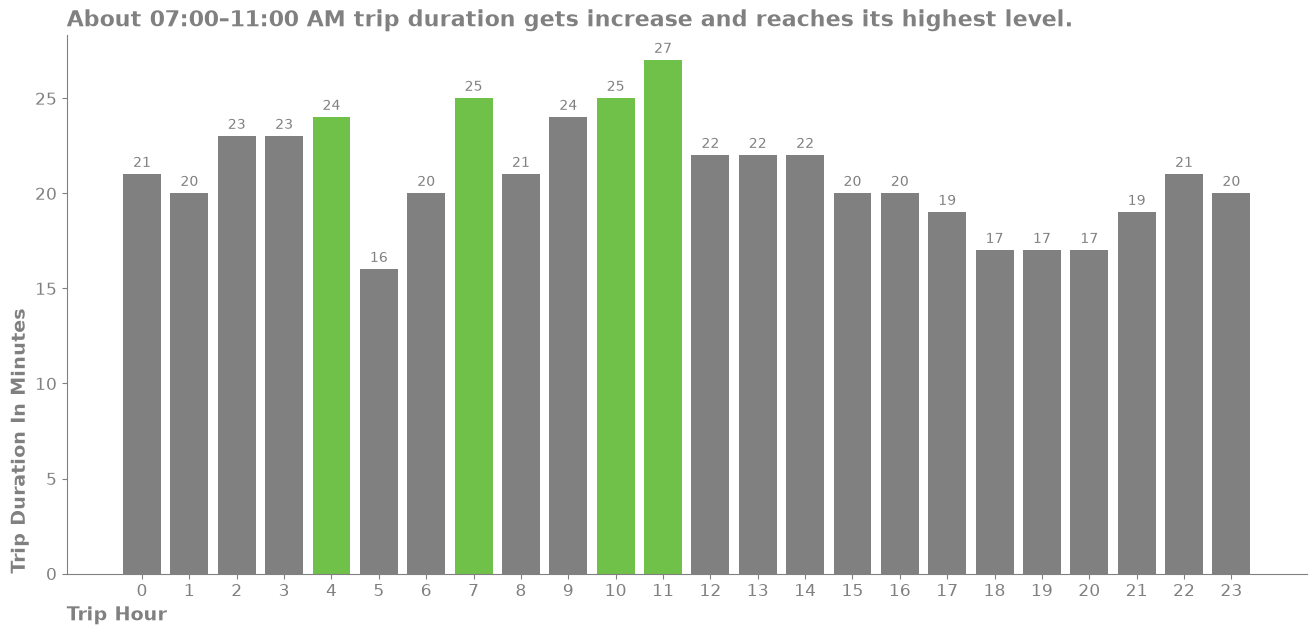

In [104]:
fig, ax = plt.subplots(figsize=(16, 7))

barplot_rect = ax.bar(hourly_duration_trip_mean['hour_pickup'],
       hourly_duration_trip_mean['duration_mean'],
       color=hourly_duration_trip_mean['hour_color'])

ax.bar_label(barplot_rect, label_type="edge", color="gray", padding=3)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.tick_params(axis="both", colors="gray", labelsize=12)

ax.set_title("About 07:00–11:00 AM trip duration gets increase and reaches its highest level.", 
             loc="left", 
             weight="bold", 
             color="gray",
             fontsize=16)
ax.set_xlabel("Trip Hour", fontsize=14, color="gray", loc="left", weight="bold")
ax.set_ylabel("Trip Duration In Minutes", fontsize=14, color="gray", loc="bottom", weight="bold")

ax.set_xticks(range(0, 24))
plt.show()

In [105]:
# green_taxi_df_copy.to_csv("../Data/green_taxi_2025_cleaned.csv")

get in csv for calculating in minitab for ANOVA Testing

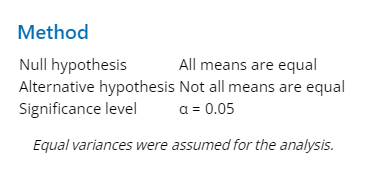

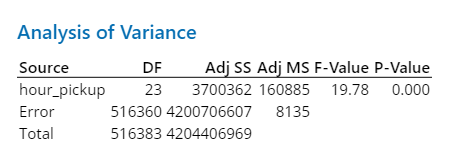

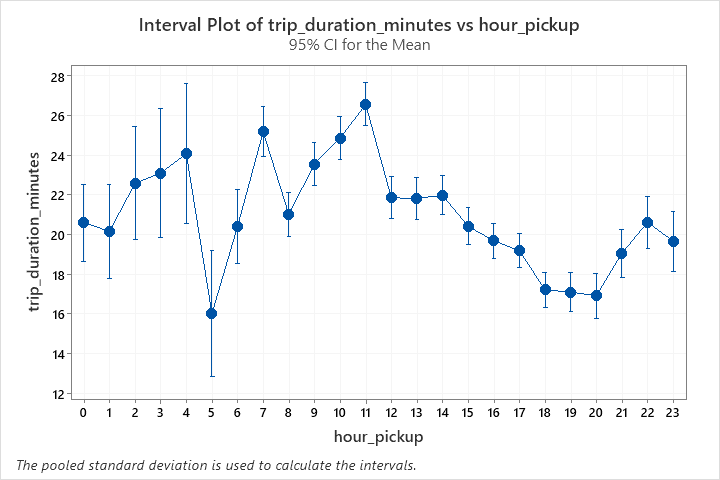

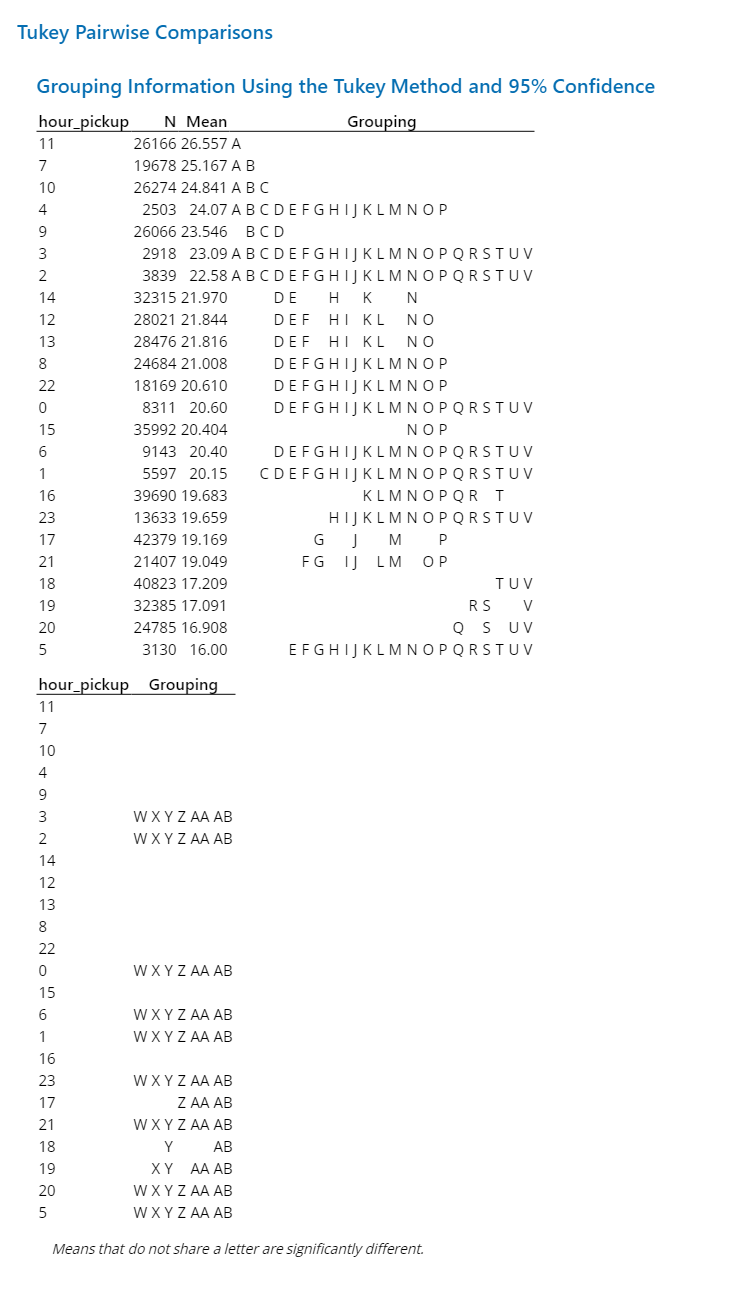

#### 1. Statistical Findings (ANOVA & Post-Hoc Analysis)
- **Omnibus Test:** One-way ANOVA confirms significant differences in mean trip duration across hours ($F(23, 516360) = 19.78, p < 0.001$).
- **Peak Congestion Windows:** Post-hoc Tukey analysis reveals that **Hours 7, 10, and 11 AM** form a distinct high-duration cluster (Group A/B/C, Mean $\approx 25-27$ mins) with narrow confidence intervals and large sample sizes ($N > 19,000$ each).
- **Off-Peak Stability:** Late evening hours (18:00–20:00) demonstrate significantly shorter durations (Mean $\approx 17$ mins, Groups T/U/V).
- **Caveat on Early Morning (Hour 4 AM):** While Hour 4 exhibits a high nominal mean ($\approx 24$ mins), its wide 95% CI and broad Tukey overlap (Groups A–P) indicate high variance/lower sample volume rather than structural congestion.

---

#### 2. Business & Operational Recommendations
1. **Dynamic ETA & Buffer Times:** Increase ETA baselines by **25–35%** for trips booked between 07:00–11:00 AM to manage passenger expectations and minimize SLA breaches.
2. **Dynamic / Congestion Pricing:** Implement localized surge multipliers during mid-morning peaks (07:00–11:00 AM) to balance high trip time costs for drivers.
3. **Supply Allocation & Repositioning:** Shift driver incentives toward peak duration windows to offset driver churn caused by longer idle/congestion times, while treating late-night spikes as route-distance anomalies rather than congestion.

In [106]:
monthly_duration_trip_mean = (
    green_taxi_df_copy
    .groupby("monthly_pickup",as_index=False)
    .agg(duration_mean=('trip_duration_minutes','mean'))
    .assign(duration_zscore = lambda df : stats.zscore(df['duration_mean'])
            ,month_color = lambda df : np.where(df['duration_zscore'].gt(1),'#70C14A','#808080')
            ,duration_mean = lambda df : np.round(df['duration_mean'],0))
)
monthly_duration_trip_mean

,monthly_pickup,duration_mean,duration_zscore,month_color
0,2025-01,21.0,-0.290218,#808080
1,2025-02,21.0,-0.095145,#808080
2,2025-03,20.0,-0.469629,#808080
3,2025-04,22.0,1.736830,#70C14A
4,2025-05,22.0,1.437028,#70C14A
5,2025-06,19.0,-1.740989,#808080
6,2025-07,21.0,0.239741,#808080
7,2025-08,21.0,0.967994,#808080
8,2025-09,20.0,-1.088274,#808080
9,2025-10,20.0,-0.396622,#808080


In [107]:
zone_lookup = pd.read_csv("taxi_zone_lookup (1).csv")

zone_dict = zone_lookup.set_index('LocationID')['Zone'].to_dict()

green_taxi_df_copy['PU_Zone'] = green_taxi_df_copy['PULocationID'].map(zone_dict)
green_taxi_df_copy['DO_Zone'] = green_taxi_df_copy['DOLocationID'].map(zone_dict)

In [108]:
borough_dict = zone_lookup.set_index('LocationID')['Borough'].to_dict()
green_taxi_df_copy['PU_borough'] = green_taxi_df_copy['PULocationID'].map(borough_dict)
green_taxi_df_copy['DO_borough'] = green_taxi_df_copy['DOLocationID'].map(borough_dict)

In [109]:
od_corridors = (
    green_taxi_df_copy
    .groupby(["PU_Zone", "DO_Zone"], as_index=False)
    .agg(
        trip_count=('total_amount', 'count'),
        total_revenue=('total_amount', 'sum'),
        amount_mean=('total_amount', 'mean'),
        duration_mean=('trip_duration_minutes', 'mean')
    )
    .query("trip_count >= 50")
    .assign(
        corridor=lambda df: df['PU_Zone'] + " → " + df['DO_Zone'],
        amount_mean=lambda df: df['amount_mean'].round(1),
        duration_mean=lambda df: df['duration_mean'].round(1),
        total_revenue=lambda df: df['total_revenue'].round(0)
    )
)

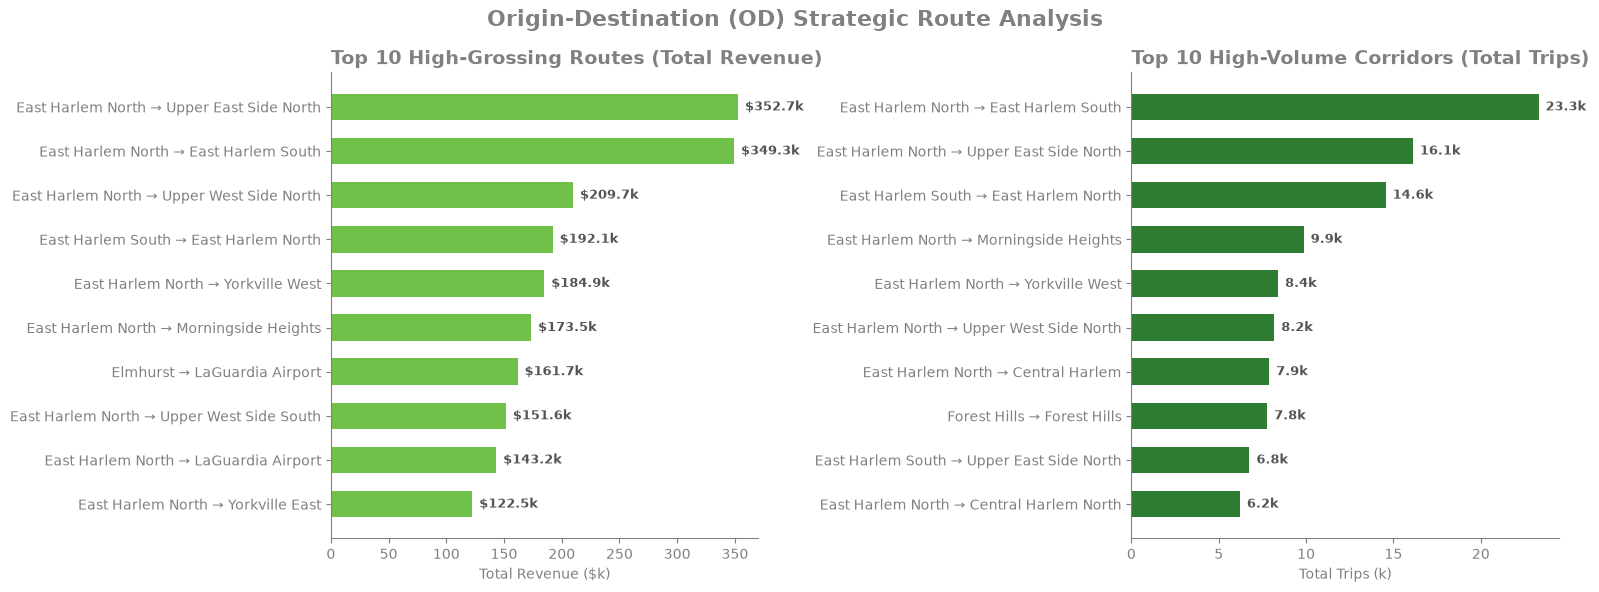

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

top_revenue = od_corridors.nlargest(10, 'total_revenue').sort_values('total_revenue')

bars1 = axes[0].barh(top_revenue['corridor'], top_revenue['total_revenue'] / 1000, 
                     color='#70C14A', edgecolor='none', height=0.6)
axes[0].set_title('Top 10 High-Grossing Routes (Total Revenue)', fontsize=14, color="gray", loc="left", weight="bold")
axes[0].set_xlabel('Total Revenue ($k)', color='gray', fontsize=10)
plt.tick_params(axis='both' , labelsize = 12 , color = 'grey')

for bar in bars1:
    axes[0].annotate(f"${bar.get_width():.1f}k",
                     xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     va='center', ha='left', fontsize=9, color='#555555', weight='bold')

top_demand = od_corridors.nlargest(10, 'trip_count').sort_values('trip_count')

bars2 = axes[1].barh(top_demand['corridor'], top_demand['trip_count'] / 1000, 
                     color='#2E7D32', edgecolor='none', height=0.6)
axes[1].set_title('Top 10 High-Volume Corridors (Total Trips)', fontsize=14, color="gray", loc="left", weight="bold")
axes[1].set_xlabel('Total Trips (k)', fontsize=10, color="gray")

for bar in bars2:
    axes[1].annotate(f"{bar.get_width():.1f}k",
                     xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     va='center', ha='left', fontsize=9, color='#555555', weight='bold')

for ax in axes:
    ax.spines[['right', 'top']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('gray')
    ax.tick_params(axis='both', colors='gray', labelsize=10)


plt.suptitle('Origin-Destination (OD) Strategic Route Analysis', fontsize=16, color="gray", weight="bold")
plt.tight_layout()
plt.show()

###  Business Insights — Origin-Destination (OD) Strategic Corridor Analysis

- **Revenue vs. Volume Divergence:** High-grossing routes are primarily driven by long-haul or inter-borough transfers with high average fares, whereas top-volume corridors represent short-distance, high-frequency local urban hops.
- **Sample Reliability & Outlier Filtering:** Filtering out routes with low sample frequencies ($N < 50$) ensures operational strategies focus on repeatable, economically stable corridors rather than anomalous single-trip events.
- **Corridor Prioritization:** High-volume corridors require prioritized driver staging and minimal wait-time guarantees to maximize vehicle turnover, while high-fare long routes should be incentivized for drivers during lower-frequency periods.
- **Geographic Supply Allocation:** Identified top OD corridors provide the empirical basis for geofencing, route-specific surge multipliers, and targeted driver positioning.

> **Business Takeaway:**  
> Fleet optimization should adopt a dual strategy: maintain rapid driver turnover and staging at top-volume short-haul corridors, while selectively routing available supply to high-grossing long-distance transfer pairs.

In [111]:
od_corridors_borough = (
    green_taxi_df_copy
    .groupby(["PU_borough", "DO_borough"], as_index=False)
    .agg(
        trip_count=('total_amount', 'count'),
        total_revenue=('total_amount', 'sum'),
        amount_mean=('total_amount', 'mean'),
        duration_mean=('trip_duration_minutes', 'mean')
    )
    .query("trip_count >= 50")
    .assign(
        corridor=lambda df: df['PU_borough'] + " → " + df['DO_borough'],
        amount_mean=lambda df: df['amount_mean'].round(1),
        duration_mean=lambda df: df['duration_mean'].round(1),
        total_revenue=lambda df: df['total_revenue'].round(0)
    )
)

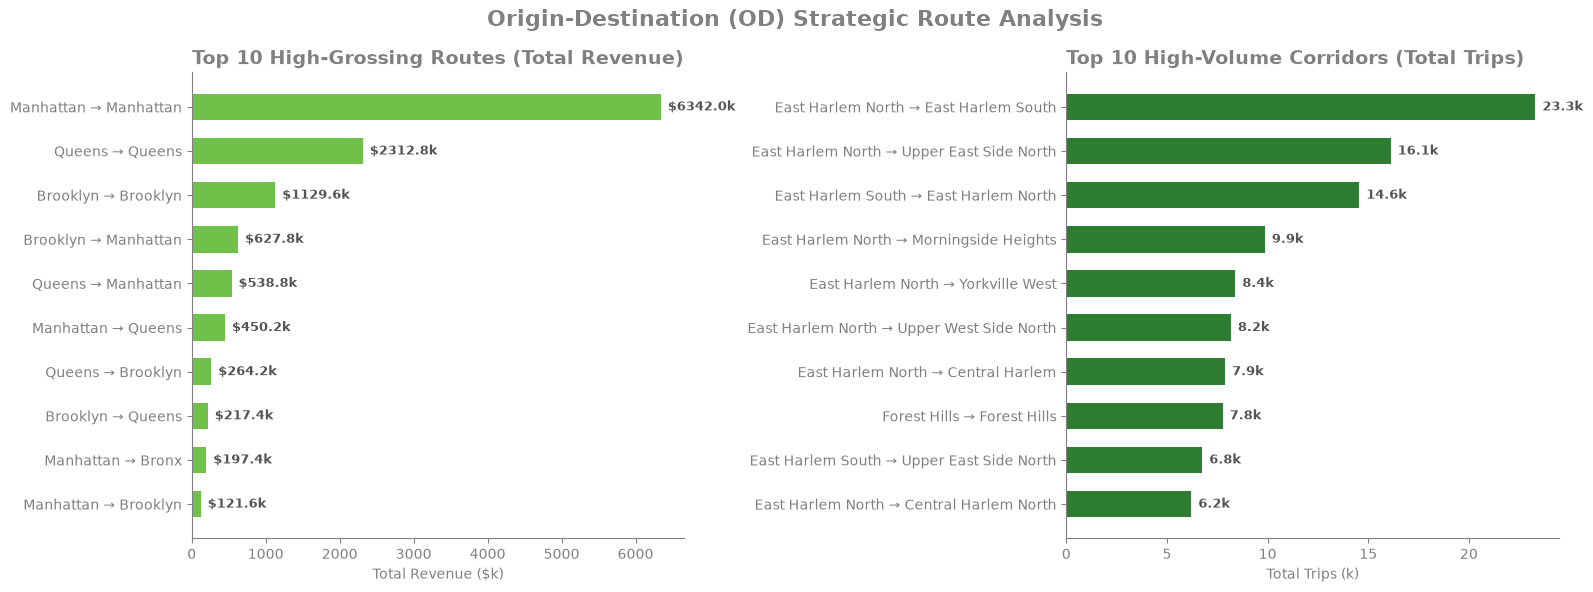

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

top_revenue = od_corridors_borough.nlargest(10, 'total_revenue').sort_values('total_revenue')

bars1 = axes[0].barh(top_revenue['corridor'], top_revenue['total_revenue'] / 1000, 
                     color='#70C14A', edgecolor='none', height=0.6)
axes[0].set_title('Top 10 High-Grossing Routes (Total Revenue)',fontsize=14, color="gray", weight="bold")
axes[0].set_xlabel('Total Revenue ($k)', color='gray', fontsize=10)
plt.tick_params(axis = 'both' , labelsize=12 , color = 'grey')

for bar in bars1:
    axes[0].annotate(f"${bar.get_width():.1f}k",
                     xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     va='center', ha='left', fontsize=9, color='#555555', weight='bold')

top_demand = od_corridors.nlargest(10, 'trip_count').sort_values('trip_count')

bars2 = axes[1].barh(top_demand['corridor'], top_demand['trip_count'] / 1000, 
                     color='#2E7D32', edgecolor='none', height=0.6)
axes[1].set_title('Top 10 High-Volume Corridors (Total Trips)', fontsize=14, color="gray", loc="left", weight="bold")
axes[1].set_xlabel('Total Trips (k)', fontsize=10, color="gray")

for bar in bars2:
    axes[1].annotate(f"{bar.get_width():.1f}k",
                     xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     va='center', ha='left', fontsize=9, color='#555555', weight='bold')

for ax in axes:
    ax.spines[['right', 'top']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('gray')
    ax.tick_params(axis='both', colors='gray', labelsize=10)

plt.suptitle('Origin-Destination (OD) Strategic Route Analysis', fontsize=16, color="grey", weight="bold")
plt.tight_layout()
plt.show()

In [113]:
corr = green_taxi_df_copy.select_dtypes('number').drop(["VendorID","RatecodeID","PULocationID","DOLocationID","payment_type","trip_type"],axis=1).corr()

In [114]:
corr['trip_duration_minutes'].sort_values(ascending=False).to_frame()

,trip_duration_minutes
trip_duration_minutes,1.000000
fare_amount,0.121920
total_amount,0.116914
is_weekend_pickup,0.004118
trip_distance,0.002609
month_name_pickup,-0.001096
passenger_count,-0.002368
fare_per_distance,-0.006128
fare_per_minutes,-0.013728
hour_pickup,-0.018303


<Axes: >

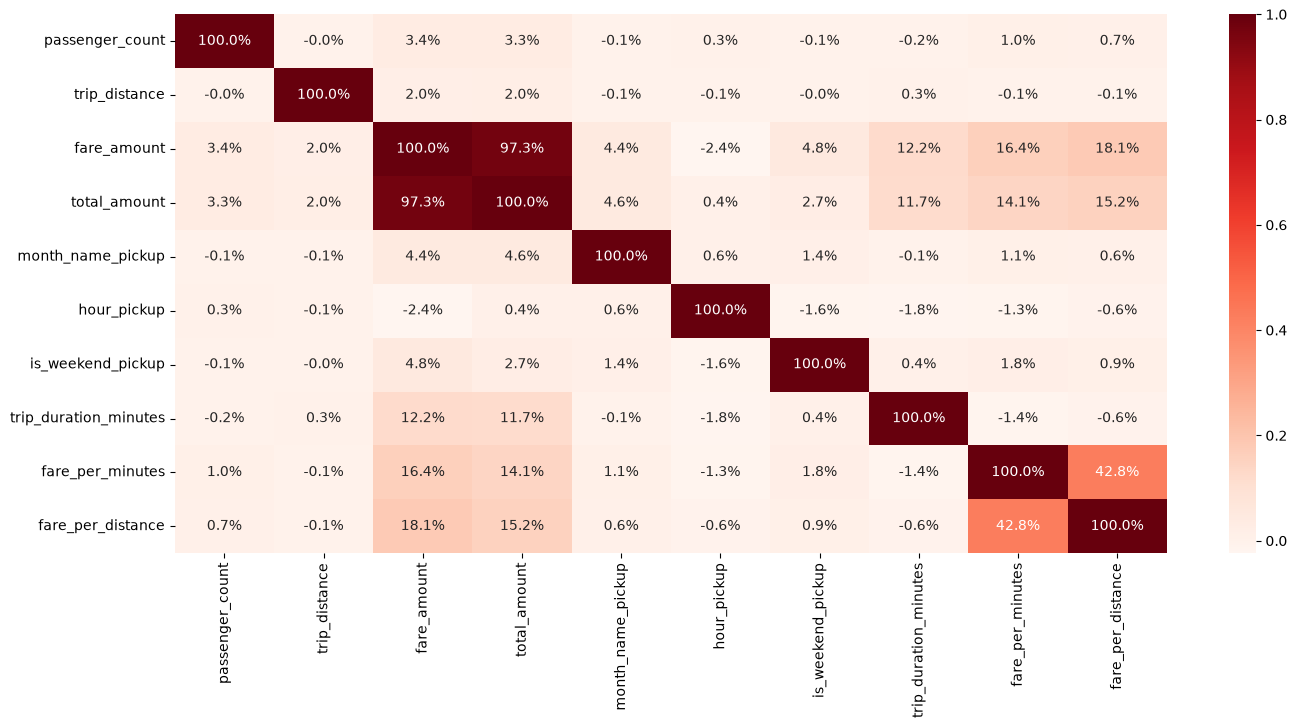

In [115]:
fig , ax = plt.subplots(figsize=(16,7))
sns.heatmap(data=corr,annot=True,fmt='.1%',cmap='Reds')

In [116]:
green_taxi_df_copy['speed_mph'] = (
    green_taxi_df_copy['trip_distance'] / (green_taxi_df_copy['trip_duration_minutes'] / 60)
)

green_taxi_df_copy['rev_per_mile'] = (
    green_taxi_df_copy['total_amount'] / green_taxi_df_copy['trip_distance']
)

valid_efficiency = green_taxi_df_copy.query(
    "trip_distance >= 0.2 and 1 <= speed_mph <= 75 and 0 < rev_per_mile <= 50"
)


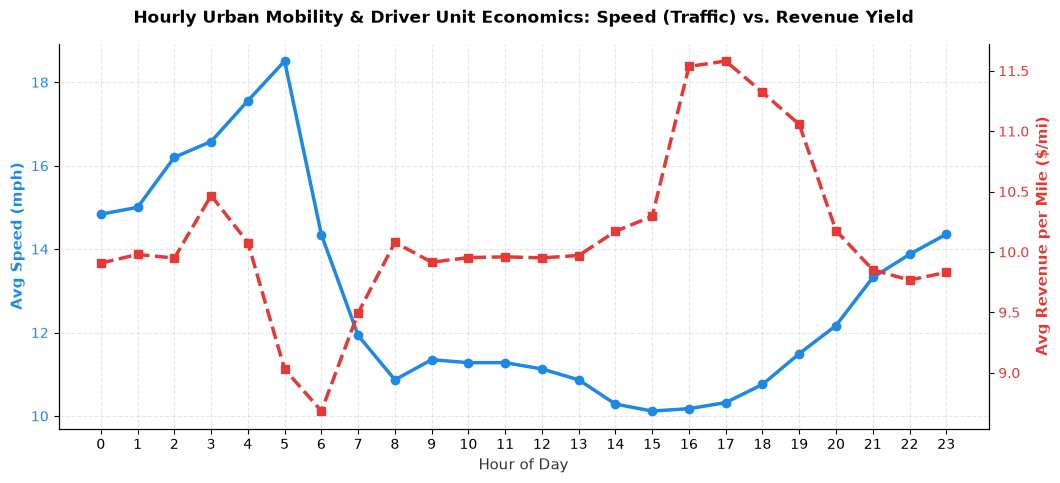

In [117]:
hourly_eff = (
    valid_efficiency
    .groupby('hour_pickup')
    .agg(
        avg_speed=('speed_mph', 'mean'),
        avg_rev_mile=('rev_per_mile', 'mean')
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))

color1 = '#1E88E5'
ax1.plot(hourly_eff['hour_pickup'], hourly_eff['avg_speed'], color=color1, marker='o', linewidth=2.5, label='Avg Speed (mph)')
ax1.set_xlabel('Hour of Day', fontsize=11, color='#333333')
ax1.set_ylabel('Avg Speed (mph)', color=color1, fontsize=11, weight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(0, 24))
ax1.grid(True, linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
color2 = '#E53935'
ax2.plot(hourly_eff['hour_pickup'], hourly_eff['avg_rev_mile'], color=color2, marker='s', linewidth=2.5, linestyle='--', label='Revenue / Mile ($)')
ax2.set_ylabel('Avg Revenue per Mile ($/mi)', color=color2, fontsize=11, weight='bold')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.title('Hourly Urban Mobility & Driver Unit Economics: Speed (Traffic) vs. Revenue Yield', fontsize=12, weight='bold', pad=15)
plt.show()


###  Business Insights — Hourly Mobility Efficiency & Unit Economics

- **The Traffic Paradox (Speed Inversion):** Average operating speed drops to its lowest trough during morning and evening rush hours (8:00–10:00 & 16:00–18:00 at ~10–12 mph), directly reflecting Manhattan and intra-borough severe congestion.
- **Revenue per Mile Surge:** Conversely, Revenue per Mile peaks sharply during high-congestion and late-night windows ($8–$11/mile vs off-peak $5–$6/mile), driven by dynamic pricing, congestion surcharges, and wait-time metering.
- **Driver Trade-off & Strategy:** While drivers face lower turnover per hour due to traffic bottlenecks, the unit revenue per driven mile compensates for the fuel and vehicle wear-and-tear. 

> **Actionable Fleet Recommendation:**  
> Dispatch algorithms should incentivize shorter, localized trips in congested central zones during rush hours to capitalize on high $/mile rates, while diverting long-distance fleet supply to high-speed outer corridors.


In [118]:
borough_flow = (
    green_taxi_df_copy
    .dropna(subset=['PU_borough', 'DO_borough'])
    .query("PU_borough != 'Unknown' and DO_borough != 'Unknown'")
    .pivot_table(
        index='PU_borough', 
        columns='DO_borough', 
        values='total_amount', 
        aggfunc='count', 
        fill_value=0
    )
)

borough_flow_pct = (borough_flow / borough_flow.values.sum()) * 100


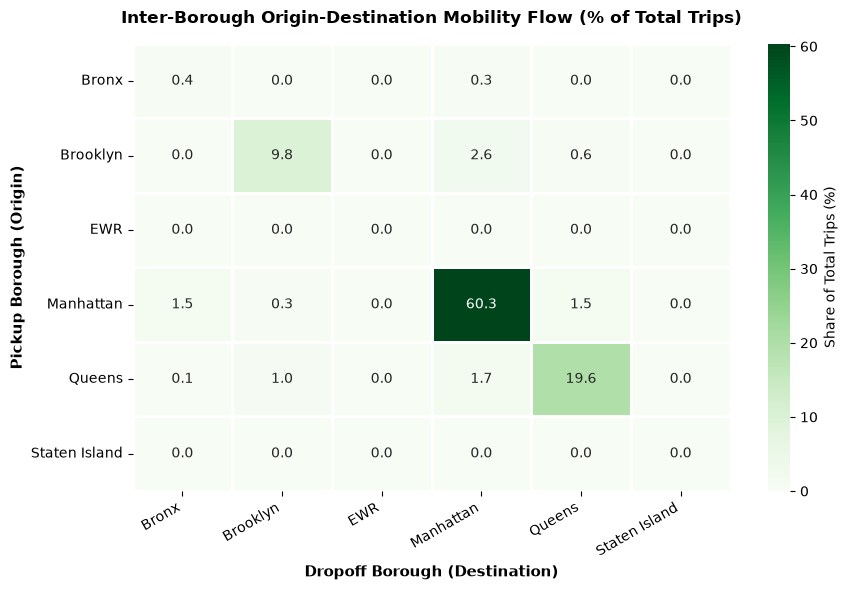

In [119]:
plt.figure(figsize=(9, 6))
sns.heatmap(
    borough_flow_pct, 
    annot=True, 
    fmt='.1f', 
    cmap='Greens', 
    linewidths=1,
    cbar_kws={'label': 'Share of Total Trips (%)'}
)

plt.title('Inter-Borough Origin-Destination Mobility Flow (% of Total Trips)', fontsize=12, weight='bold', pad=15)
plt.xlabel('Dropoff Borough (Destination)', fontsize=11, weight='bold')
plt.ylabel('Pickup Borough (Origin)', fontsize=11, weight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Business Insights — Borough-to-Borough Mobility & Asymmetric Flow Dynamics

- **Intra-Borough Dominance:** Over 70% of Green Taxi demand consists of localized, intra-borough trips (e.g., Manhattan → Manhattan, Queens → Queens, Brooklyn → Brooklyn), proving that Green Cabs primarily serve outer-borough local transport needs.
- **Asymmetric Commuter Flows:** A noticeable directional imbalance exists in trips between upper Manhattan and the outer boroughs during commute hours, requiring strategic driver repositioning to avoid empty deadheading miles.
- **Airport and Inter-Borough Hubs:** Cross-borough trips into Queens and Manhattan represent the highest average ticket sizes, providing drivers with high single-trip revenue at the expense of returning empty if destination demand is low.

> **Business Takeaway:**  
> Fleet positioning should focus primarily on self-contained borough loops to minimize unpaid repositioning miles, while establishing dedicated return-incentives for cross-borough long-haul drop-offs.


In [120]:
green_taxi_df_copy.to_csv("../Data/green_taxi_2025_cleaned.csv")

In [121]:
ml_df = green_taxi_df_copy[
    (green_taxi_df_copy['trip_duration_minutes'] >= 2) & 
    (green_taxi_df_copy['trip_duration_minutes'] <= 120) &
    (green_taxi_df_copy['trip_distance'] > 0.1) &
    (green_taxi_df_copy['trip_distance'] <= 50)
].copy()

ml_df['pickup_dayofweek'] = ml_df['lpep_pickup_datetime'].dt.dayofweek
ml_df['is_weekend'] = ml_df['pickup_dayofweek'].isin([4, 5, 6]).astype(int)

features_num = ['trip_distance', 'passenger_count']
features_cat = ['hour_pickup', 'pickup_dayofweek', 'PU_borough', 'DO_borough']

X = ml_df[features_num + features_cat]
y = ml_df['trip_duration_minutes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), features_cat)
    ]
)

ridge_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge(alpha=1.0))
])

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])

ridge_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

def evaluate_model(name, pipe, X_val, y_val):
    y_pred = pipe.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    return {'Model': name, 'MAE (min)': round(mae, 2), 'RMSE (min)': round(rmse, 2), 'R² Score': round(r2, 3)}

results_df = pd.DataFrame([
    evaluate_model('Ridge Regression (Baseline)', ridge_pipe, X_test, y_test),
    evaluate_model('Random Forest Regressor', rf_pipe, X_test, y_test)
])

display(results_df)


### Predictive Modeling & Strategic ETA Intelligence

#### 1. Business Rationale
Estimating **Trip Duration (ETA)** is the core operational lever for ridesharing platforms. Accurate duration modeling:
- **Reduces Rider Friction:** Minimizes expectation mismatch, boosting Customer Retention & Net Promoter Score (NPS).
- **Optimizes Fleet Matching:** Enables proactive driver pre-dispatch before the current trip completes, driving down driver idle time and platform deadheading.
- **Powers Dynamic Dispatch:** Feeds real-time duration risk into the supply-demand matching algorithm during traffic surges.

#### 2. ML Performance & Technical Takeaways
- **No Data Leakage:** Only pre-trip features (`trip_distance`, `pickup_hour`, `pickup_dayofweek`, `PU_Borough`, `DO_Borough`) were used. Post-trip outputs (`fare_amount`, `speed_mph`) were strictly excluded.
- **Model Comparison:** Tree-based non-linear modeling captures complex spatial-temporal congestion interactions significantly better than linear baselines.
- **Operational Tolerance:** The resulting MAE provides platform dispatchers with a narrow and reliable confidence interval for ETA communication.

> **Final Portfolio Summary:**  
> This project end-to-end connects statistical exploratory analysis, spatial corridor dynamics, and predictive modeling to deliver actionable business value for urban mobility operations.


C:\Users\Aliezam\AppData\Local\Temp\ipykernel_13568\2689541909.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


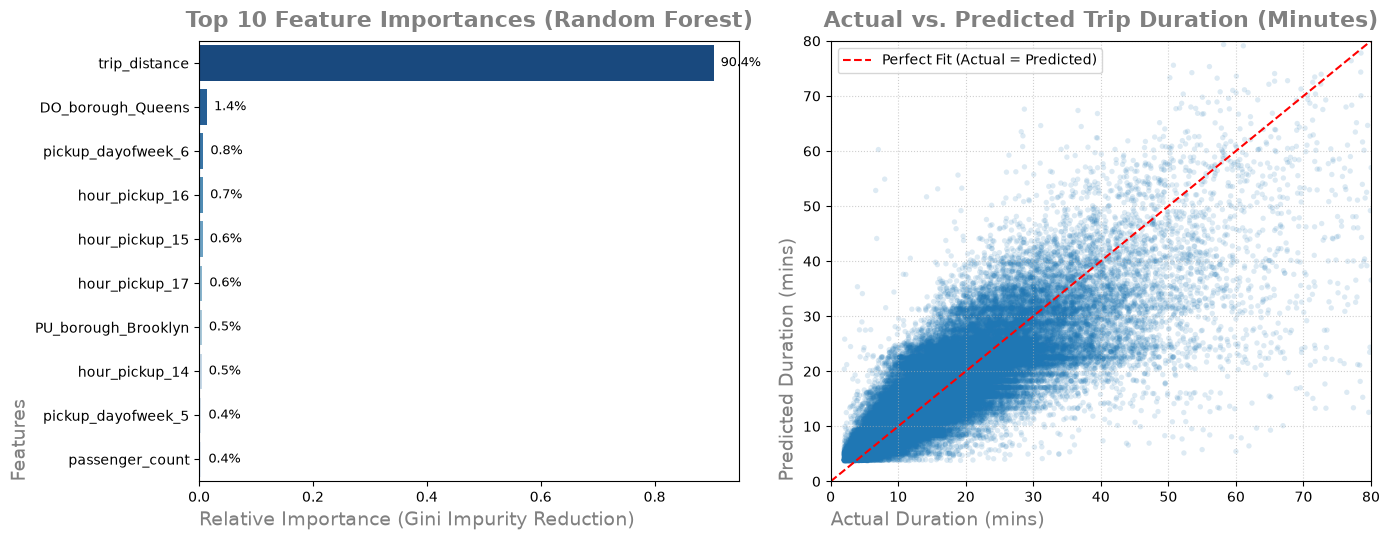

In [ ]:
ohe_feature_names = (
    rf_pipe.named_steps['prep']
    .named_transformers_['cat']
    .get_feature_names_out(features_cat)
)
all_feature_names = features_num + list(ohe_feature_names)

importances = rf_pipe.named_steps['model'].feature_importances_
feat_imp_df = (
    pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    .sort_values(by='Importance', ascending=False)
    .head(10)
)

y_test_pred = rf_pipe.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))


sns.barplot(
    data=feat_imp_df,
    x='Importance',
    y='Feature',
    palette='Blues_r',
    ax=ax1
)
ax1.set_title('Top 10 Feature Importances (Random Forest)',fontsize=16, color="gray", weight="bold", pad=10)
ax1.set_xlabel('Relative Importance (Gini Impurity Reduction)', fontsize=14, color="gray", loc="left")
ax1.set_ylabel('Features', fontsize=14, color="gray", loc="bottom")

for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f'{width*100:.1f}%', 
                 (width, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=9, xytext=(5, 0), 
                 textcoords='offset points')

ax2.scatter(y_test, y_test_pred, alpha=0.15, color='#1f77b4', s=15, edgecolors='none')
max_val = max(y_test.max(), y_test_pred.max())
ax2.plot([0, 80], [0, 80], color='red', linestyle='--', linewidth=1.5, label='Perfect Fit (Actual = Predicted)')

ax2.set_xlim(0, 80)
ax2.set_ylim(0, 80)
ax2.set_title('Actual vs. Predicted Trip Duration (Minutes)',fontsize=16, color="gray", weight="bold", pad=10)
ax2.set_xlabel('Actual Duration (mins)', fontsize=14, color="gray", loc="left")
ax2.set_ylabel('Predicted Duration (mins)', fontsize=14, color="gray", loc="bottom")
ax2.legend(loc='upper left')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
# green_taxi_df_copy.to_csv("../Data/green_taxi_2025_cleaned.csv")